# Library

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.2 MB/s eta 0:00:00


In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 84.6 MB/s eta 0:00:00


In [ ]:
# Import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import statsmodels.api as sm
import optuna
from numpy import mean
from numpy import std
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from scipy.spatial import distance_matrix
from sklearn.neighbors import NearestNeighbors
from libpysal.weights import KNN
from esda.moran import Moran
from statsmodels.stats.diagnostic import het_breuschpagan, het_white
from optuna.samplers import TPESampler
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors


# Import Data

In [ ]:
# 1) Baca Excel (sheet pertama)
df = pd.read_excel("/content/Data Skripsi Full.xlsx")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1583 entries, 0 to 1582
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       1583 non-null   float64
 1   Latitude        1583 non-null   float64
 2   periode         1583 non-null   object 
 3   id_wpp_tangkap  1583 non-null   int64  
 4   so              1583 non-null   float64
 5   thetao          1583 non-null   float64
 6   zos             1583 non-null   float64
 7   uo              1583 non-null   float64
 8   vo              1583 non-null   float64
 9   chl             1583 non-null   float64
 10  o2              1583 non-null   float64
 11  mlotst          1583 non-null   float64
 12  nppv            1583 non-null   float64
 13  Kecepatan       1583 non-null   float64
 14  cpue            1583 non-null   float64
dtypes: float64(13), int64(1), object(1)
memory usage: 185.6+ KB


In [ ]:
WPP = pd.read_csv("/content/WPP 572_573.csv", sep =';')

In [ ]:
WPP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
dtypes: float64(6), int64(3)
memory usage: 43.0 KB


## Missing value


In [ ]:
df.isna().sum()

,0
Longitude,0
Latitude,0
periode,0
id_wpp_tangkap,0
so,0
thetao,0
zos,0
uo,0
vo,0
chl,0


## Statistik Deskriptif

In [ ]:
df.describe()

,Longitude,Latitude,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue
count,1583.000000,1583.000000,1583.00000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000,1583.000000
mean,107.438566,-6.699779,572.55338,33.748653,28.665461,0.512219,-0.148165,-0.025906,0.237774,202.593894,19.631813,13.192651,0.221479,9.460825
std,9.551575,4.733729,0.49730,0.529785,1.016045,0.123111,0.221723,0.077974,0.306409,3.883281,6.623713,20.651308,0.169693,17.319075
min,92.250000,-13.750000,572.00000,31.114102,25.918408,0.202413,-0.768959,-0.607629,0.081074,178.812339,10.167482,1.421484,0.001650,0.000072
25%,98.750000,-10.250000,572.00000,33.503919,27.750721,0.443752,-0.338380,-0.059650,0.097566,199.831996,14.537267,2.926775,0.079997,0.423073
50%,106.750000,-8.250000,573.00000,33.787042,28.890697,0.525577,-0.089148,-0.022437,0.117965,200.830212,17.921148,4.364353,0.159137,1.843771
75%,116.250000,-3.250000,573.00000,34.089295,29.334334,0.585140,0.030773,0.020959,0.239142,204.961210,23.394699,13.523554,0.348778,8.691877
max,125.750000,5.750000,573.00000,34.961383,30.496962,0.773223,0.344260,0.263403,3.971957,219.270573,43.532678,215.510166,0.769938,99.604130


## Eksplorasi Scatter Plot

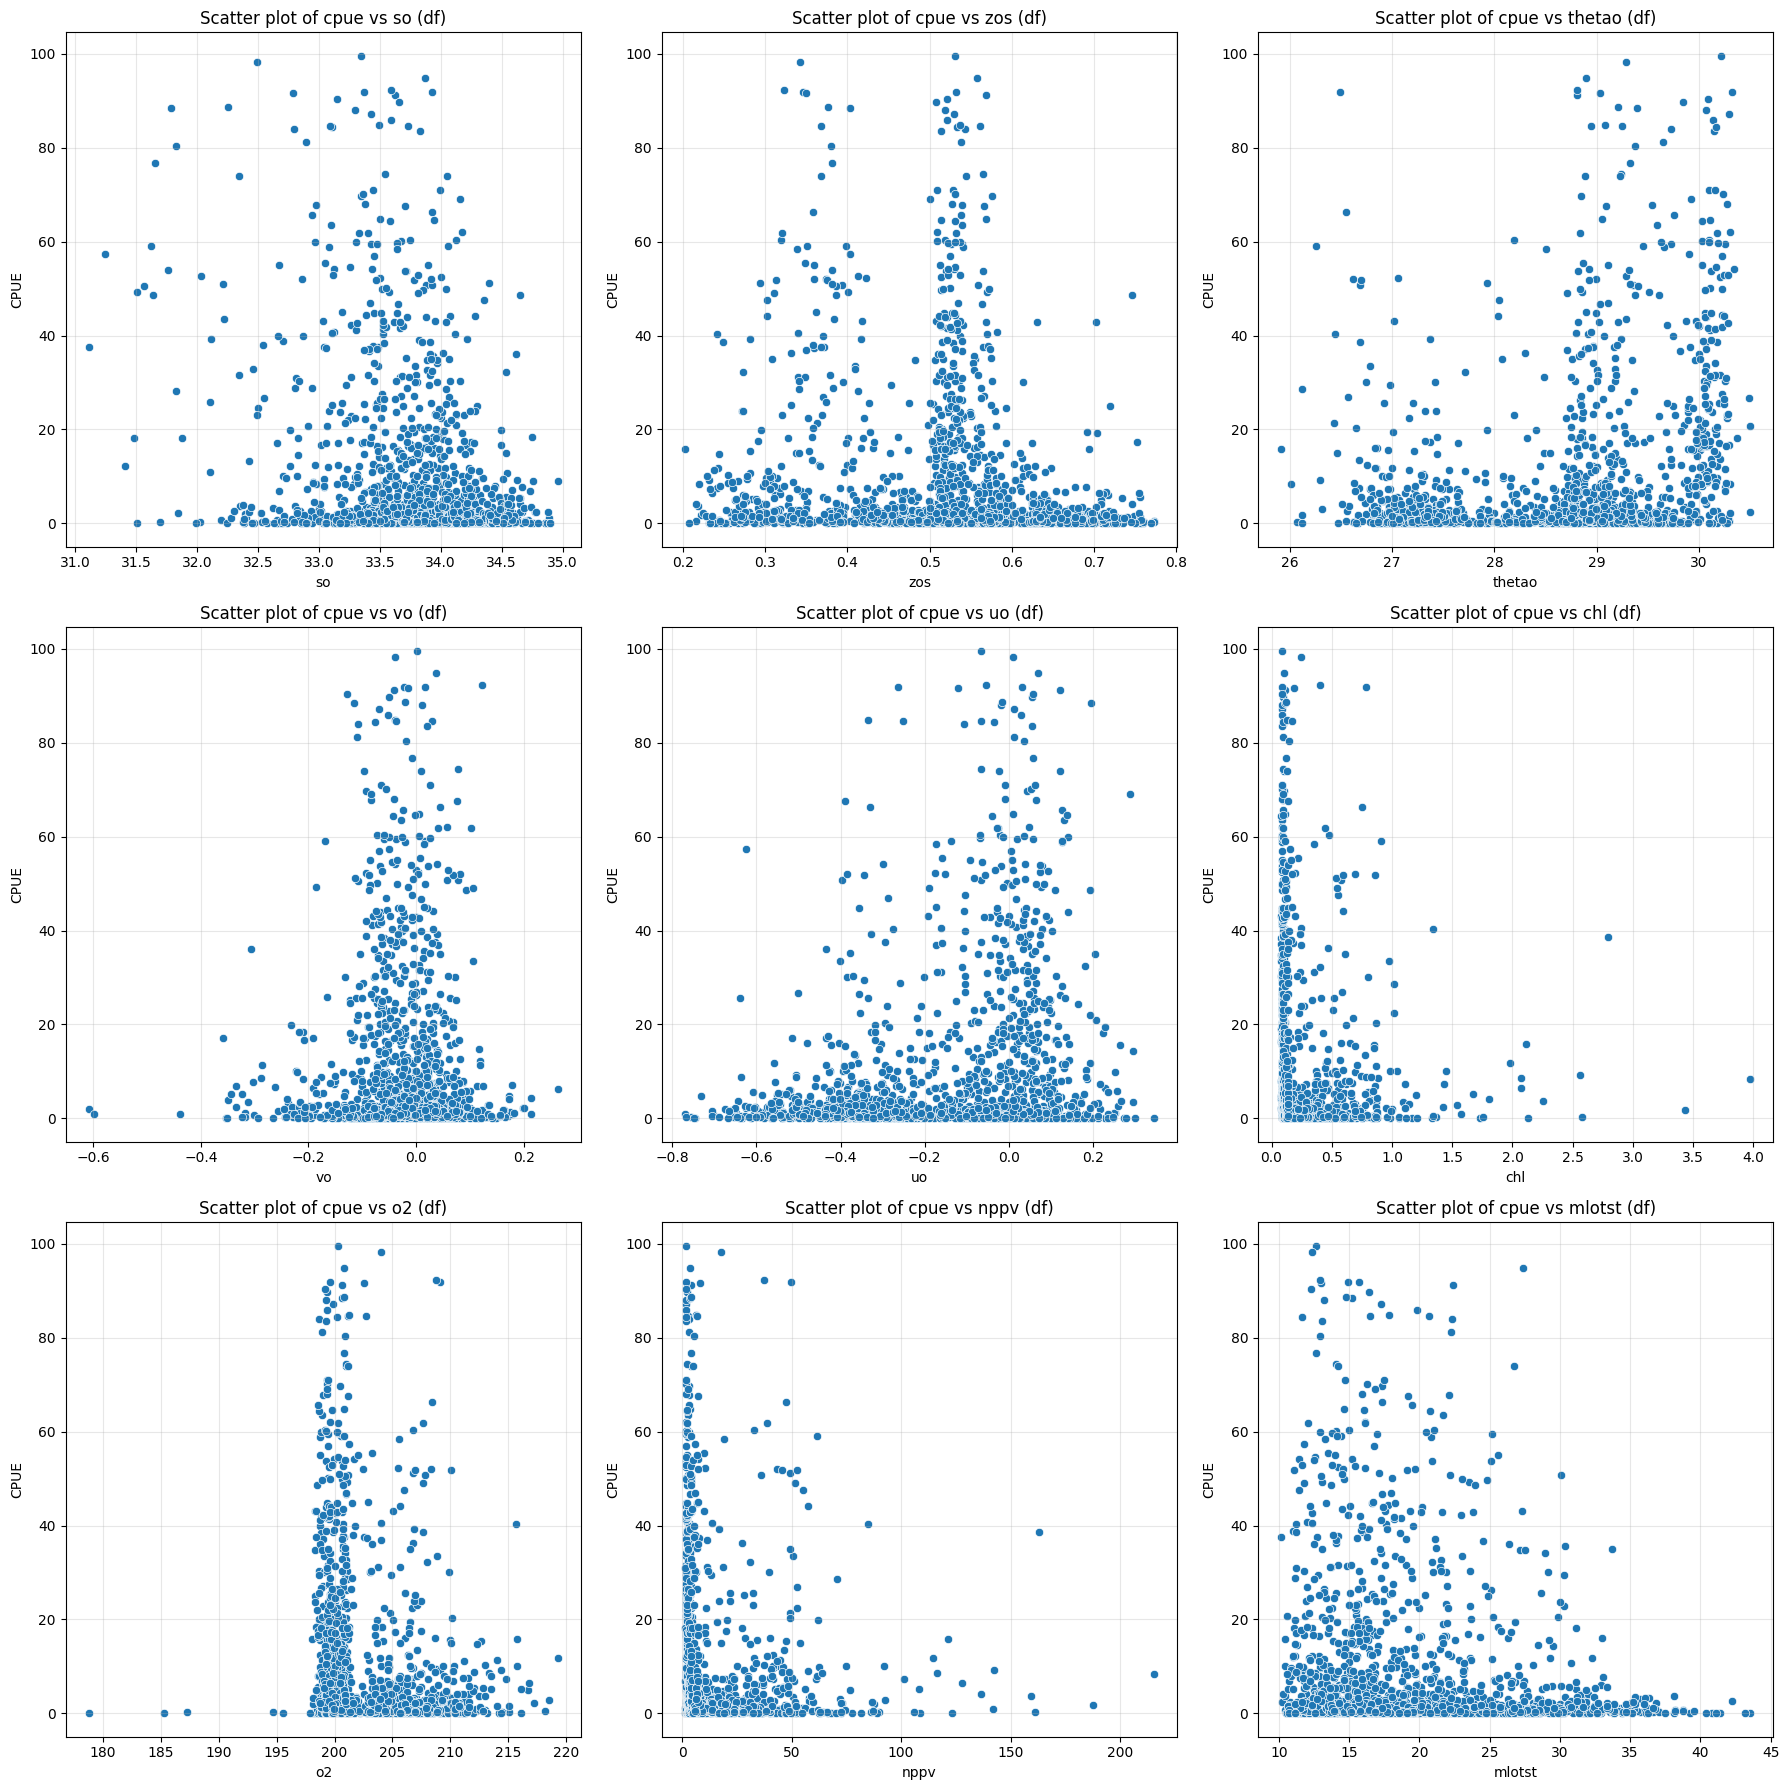

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(3, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=df, x=var, y='cpue')
    plt.title(f'Scatter plot of cpue vs {var} (df)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Boxplot

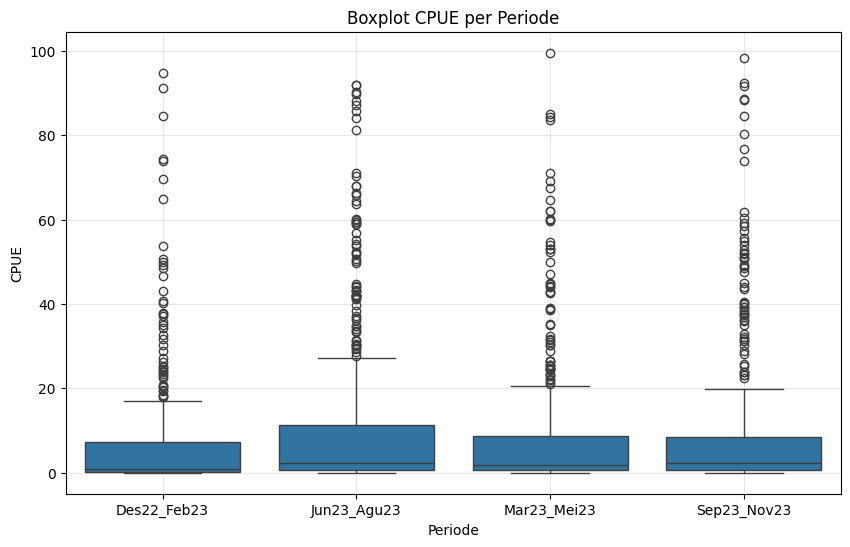

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

def adjusted_boxplot_stats(data):
    data = pd.Series(data).dropna()

    q1 = data.quantile(0.25)
    median = data.quantile(0.50)
    q3 = data.quantile(0.75)
    iqr = q3 - q1

    y = np.asarray(data, dtype=np.double)
    MC = sm.stats.stattools.medcouple(y)

    if MC > 0:
        lower_fence = q1 - 1.5 * np.exp(-4 * MC) * iqr
        upper_fence = q3 + 1.5 * np.exp(3 * MC) * iqr
    else:
        lower_fence = q1 - 1.5 * np.exp(-3 * MC) * iqr
        upper_fence = q3 + 1.5 * np.exp(4 * MC) * iqr

    # whisker adalah nilai data paling ekstrem yang masih berada dalam fence
    non_outliers = data[(data >= lower_fence) & (data <= upper_fence)]
    outliers = data[(data < lower_fence) | (data > upper_fence)]

    return {
        "q1": q1,
        "med": median,
        "q3": q3,
        "whislo": non_outliers.min(),
        "whishi": non_outliers.max(),
        "fliers": outliers.values,
        "mc": MC,
        "lower_fence": lower_fence,
        "upper_fence": upper_fence
    }

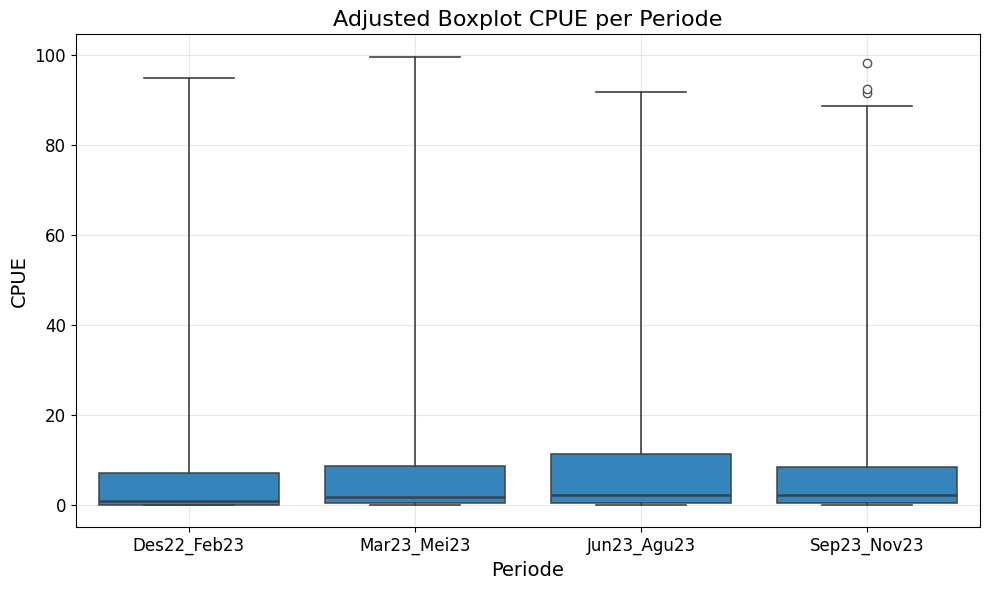

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===============================
# 1. Tentukan urutan periode
# ===============================
periode_order = [
    "Des22_Feb23",
    "Mar23_Mei23",
    "Jun23_Agu23",
    "Sep23_Nov23"
]

df["periode"] = pd.Categorical(
    df["periode"],
    categories=periode_order,
    ordered=True
)

# ===============================
# 2. Hitung adjusted boxplot stats
# ===============================
box_stats = []

for periode in periode_order:
    data_periode = df.loc[df["periode"] == periode, "cpue"]

    if len(data_periode) == 0:
        continue

    stats = adjusted_boxplot_stats(data_periode)
    stats["label"] = periode
    box_stats.append(stats)

# ===============================
# 3. Plot
# ===============================
fig, ax = plt.subplots(figsize=(10, 6))

artists = ax.bxp(
    box_stats,
    showfliers=True,
    patch_artist=True,
    widths=0.8
)

# ===============================
# 4. Styling
# ===============================
for box in artists["boxes"]:
    box.set(facecolor="#1f77b4", edgecolor="0.25", linewidth=1.2, alpha=0.9)

for median in artists["medians"]:
    median.set(color="0.25", linewidth=1.8)

for whisker in artists["whiskers"]:
    whisker.set(color="0.25", linewidth=1.2)

for cap in artists["caps"]:
    cap.set(color="0.25", linewidth=1.2)

for flier in artists["fliers"]:
    flier.set(marker="o", markerfacecolor="white",
              markeredgecolor="0.25", markersize=6,
              linestyle="none", alpha=0.9)

# ===============================
# 5. Label & grid (DIPERBESAR)
# ===============================
ax.set_title("Adjusted Boxplot CPUE per Periode", fontsize=16)

ax.set_xlabel("Periode", fontsize=14)
ax.set_ylabel("CPUE", fontsize=14)

# ukuran angka di sumbu (ini yang sering kelupaan)
ax.tick_params(axis='x', labelsize=12)
ax.tick_params(axis='y', labelsize=12)

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Urutkan periode
periode_order = sorted(df["periode"].dropna().unique())

# Hitung statistik adjusted boxplot untuk setiap periode
box_stats = []

for periode in periode_order:
    data_periode = df.loc[df["periode"] == periode, "cpue"]
    stats = adjusted_boxplot_stats(data_periode)
    stats["label"] = periode
    box_stats.append(stats)

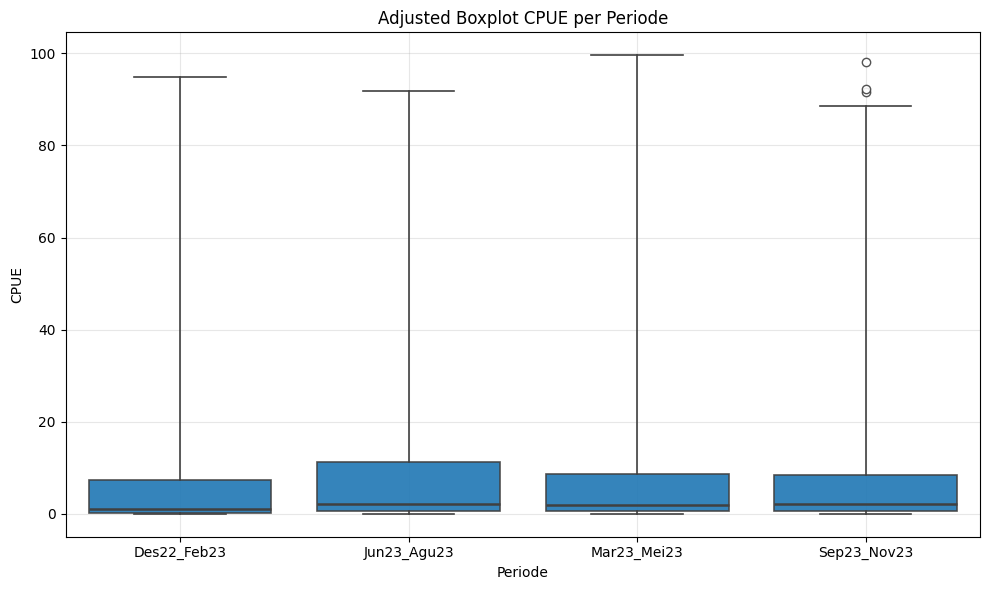

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

artists = ax.bxp(
    box_stats,
    showfliers=True,
    patch_artist=True,
    widths=0.8
)

# Warna box seperti plot kamu
for box in artists["boxes"]:
    box.set(
        facecolor="#1f77b4",
        edgecolor="0.25",
        linewidth=1.2,
        alpha=0.9
    )

# Median
for median in artists["medians"]:
    median.set(
        color="0.25",
        linewidth=1.8
    )

# Whisker
for whisker in artists["whiskers"]:
    whisker.set(
        color="0.25",
        linewidth=1.2
    )

# Cap / garis ujung whisker
for cap in artists["caps"]:
    cap.set(
        color="0.25",
        linewidth=1.2
    )

# Outlier seperti gambar: lingkaran putih pinggir abu-abu
for flier in artists["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="0.25",
        markersize=6,
        linestyle="none",
        alpha=0.9
    )

ax.set_title("Adjusted Boxplot CPUE per Periode", fontsize=12)
ax.set_xlabel("Periode")
ax.set_ylabel("CPUE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df['cpue_transformed'] = np.log1p(df['cpue'])
df.head()

,Longitude,Latitude,periode,id_wpp_tangkap,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue,cpue_transformed
0,92.25,2.75,Des22_Feb23,572,33.962241,28.953252,0.536405,-0.141075,0.010665,0.107391,201.216329,16.318926,4.061032,0.141477,18.318995,2.961089
1,92.25,3.25,Des22_Feb23,572,33.930846,29.062583,0.542085,-0.158578,0.032903,0.100964,201.194042,16.306210,3.584600,0.161955,15.934011,2.829324
2,92.75,1.25,Des22_Feb23,572,34.041546,28.774475,0.531435,0.012558,-0.054329,0.126704,201.143570,18.354906,5.410838,0.055761,9.870458,2.386049
3,93.25,0.75,Des22_Feb23,572,34.077844,28.788351,0.535326,0.112574,-0.022284,0.115972,201.043730,23.588266,4.681760,0.114758,30.287245,3.443210
4,93.25,1.25,Des22_Feb23,572,34.020678,28.805373,0.535775,0.023030,-0.028128,0.117965,201.124162,19.194165,4.774173,0.036353,18.029441,2.945987


In [ ]:
# Urutkan periode
periode_order = sorted(df["periode"].dropna().unique())

# Hitung statistik adjusted boxplot untuk setiap periode
box_stats = []

for periode in periode_order:
    data_periode = df.loc[df["periode"] == periode, "cpue_transformed"]
    stats = adjusted_boxplot_stats(data_periode)
    stats["label"] = periode
    box_stats.append(stats)

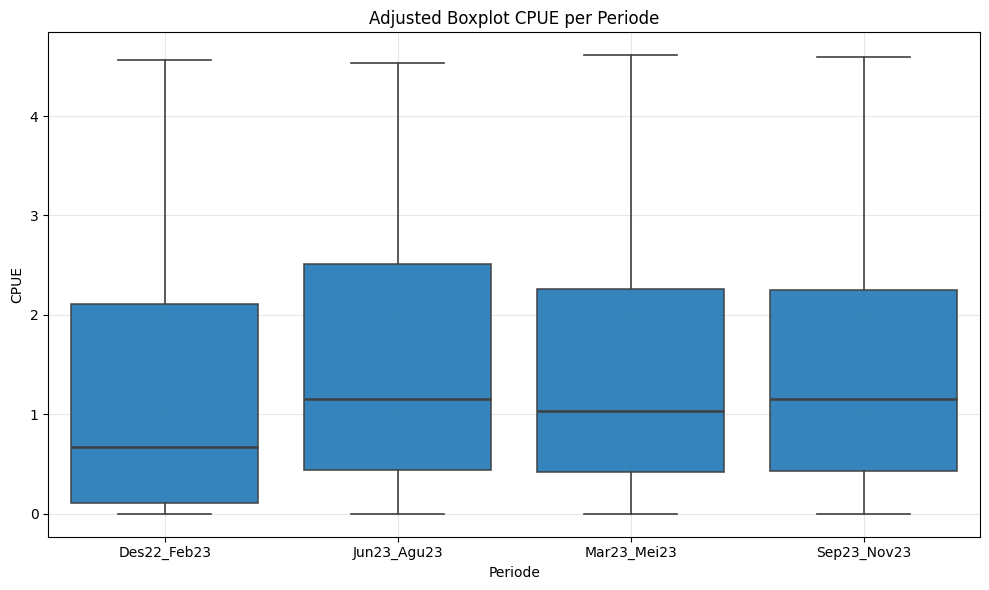

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

artists = ax.bxp(
    box_stats,
    showfliers=True,
    patch_artist=True,
    widths=0.8
)

# Warna box seperti plot kamu
for box in artists["boxes"]:
    box.set(
        facecolor="#1f77b4",
        edgecolor="0.25",
        linewidth=1.2,
        alpha=0.9
    )

# Median
for median in artists["medians"]:
    median.set(
        color="0.25",
        linewidth=1.8
    )

# Whisker
for whisker in artists["whiskers"]:
    whisker.set(
        color="0.25",
        linewidth=1.2
    )

# Cap / garis ujung whisker
for cap in artists["caps"]:
    cap.set(
        color="0.25",
        linewidth=1.2
    )

# Outlier seperti gambar: lingkaran putih pinggir abu-abu
for flier in artists["fliers"]:
    flier.set(
        marker="o",
        markerfacecolor="white",
        markeredgecolor="0.25",
        markersize=6,
        linestyle="none",
        alpha=0.9
    )

ax.set_title("Adjusted Boxplot CPUE per Periode", fontsize=12)
ax.set_xlabel("Periode")
ax.set_ylabel("CPUE")

ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

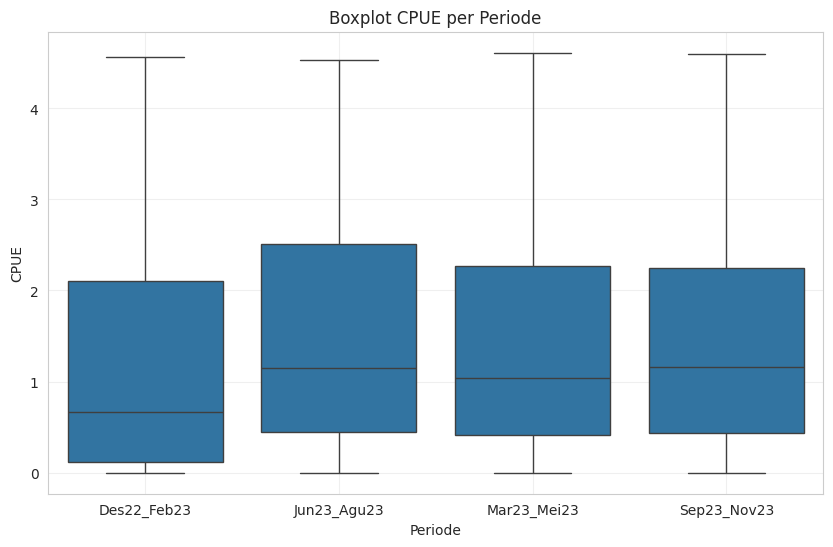

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='periode', y='cpue_transformed')
plt.title('Boxplot CPUE per Periode')
plt.xlabel('Periode')
plt.ylabel('CPUE')
plt.grid(alpha=0.3)
plt.show()

# Desember 2022 - Februari 2023

In [ ]:
# 1) Baca Excel (sheet pertama)
data = pd.read_excel("/content/Desember 2022 -Februari 2023.xlsx")

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Longitude       300 non-null    float64
 1   Latitude        300 non-null    float64
 2   periode         300 non-null    object 
 3   id_wpp_tangkap  300 non-null    int64  
 4   cpue            300 non-null    float64
 5   n_trip          300 non-null    int64  
 6   so              300 non-null    float64
 7   thetao          300 non-null    float64
 8   zos             300 non-null    float64
 9   uo              300 non-null    float64
 10  vo              300 non-null    float64
 11  chl             300 non-null    float64
 12  o2              300 non-null    float64
 13  mlotst          300 non-null    float64
 14  nppv            300 non-null    float64
 15  Kecepatan       300 non-null    float64
 16  cpue_new        300 non-null    float64
dtypes: float64(14), int64(2), object(1)

In [ ]:
data.describe()

,Longitude,Latitude,id_wpp_tangkap,cpue,n_trip,so,thetao,zos,uo,vo,chl,o2,mlotst,nppv,Kecepatan,cpue_new
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,106.163333,-6.008333,572.496667,12.788900,19.283333,33.770384,29.005845,0.621335,0.049939,0.011408,0.105989,200.235701,23.345367,3.628230,0.112973,7.755339
std,9.335129,4.708822,0.500824,56.244561,58.685059,0.398901,0.351177,0.063666,0.097862,0.067893,0.013806,0.841905,5.682849,1.274883,0.063353,15.576692
min,92.250000,-13.750000,572.000000,0.000498,1.000000,32.395635,28.400433,0.531435,-0.217597,-0.237462,0.083414,197.911181,10.459282,1.869791,0.004188,0.000498
25%,98.250000,-9.750000,572.000000,0.118844,2.000000,33.546020,28.760777,0.565846,-0.013312,-0.027403,0.098912,199.953326,20.119341,3.041743,0.068017,0.118844
50%,105.000000,-7.750000,572.000000,0.950634,4.000000,33.799709,28.875769,0.609337,0.058872,0.015239,0.102316,200.433248,23.478766,3.288027,0.098219,0.950634
75%,112.250000,-1.250000,573.000000,7.210501,10.000000,34.007400,29.165968,0.671884,0.102794,0.045574,0.108871,200.822909,26.802246,3.938944,0.146318,7.210501
max,125.750000,4.750000,573.000000,869.404520,573.000000,34.654672,30.175824,0.773223,0.344260,0.213635,0.174088,201.702175,38.172158,11.923381,0.344744,94.810576


## Eksplorasi Scatter Plot

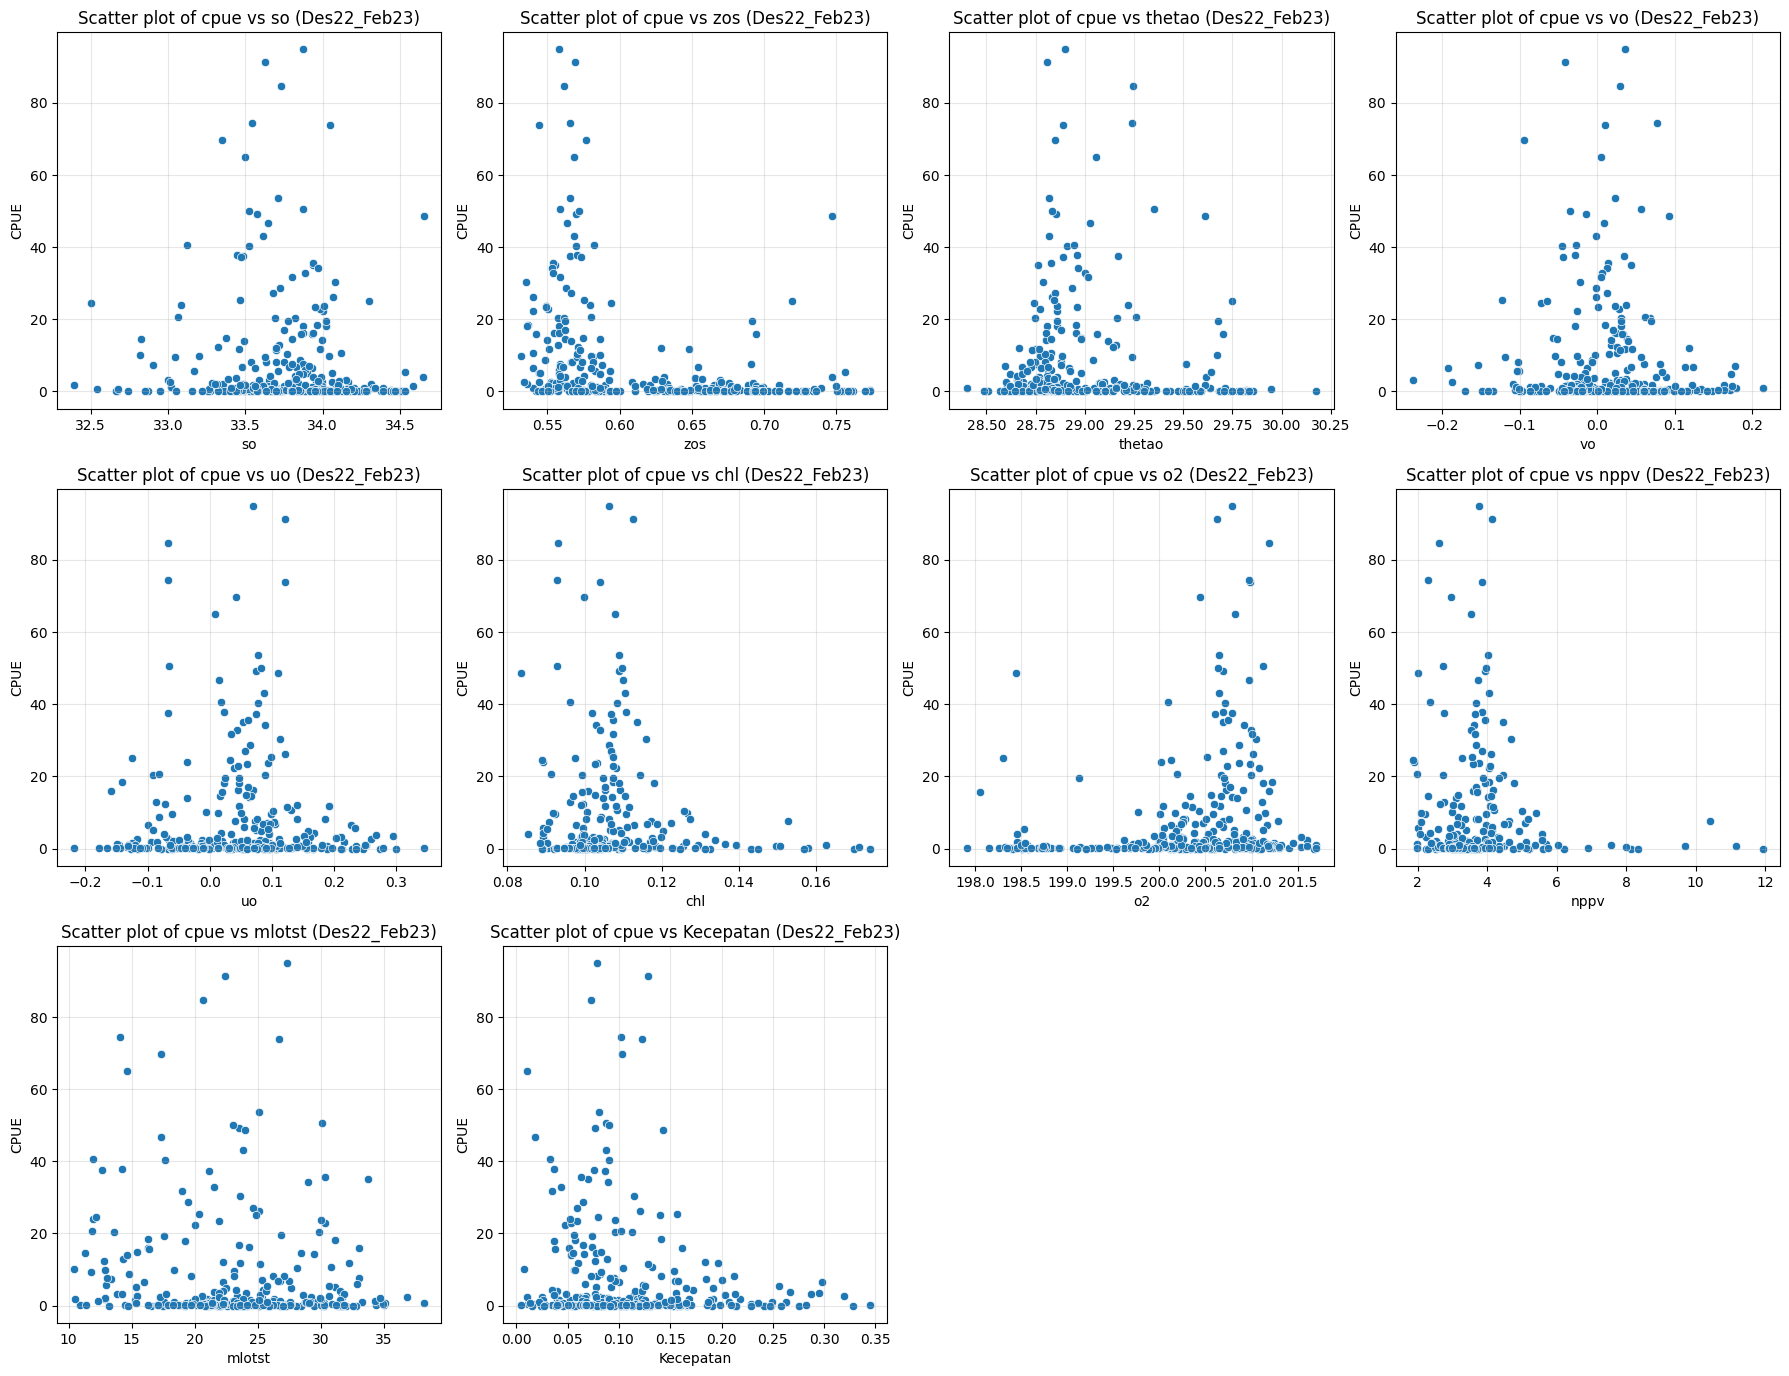

In [ ]:
environmental_vars = ['so', 'zos', 'thetao', 'vo', 'uo', 'chl', 'o2', 'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 18)) # Adjust figure size to accommodate more plots
for i, var in enumerate(environmental_vars):
    plt.subplot(4, 4, i + 1) # Arrange plots in a 3x3 grid
    sns.scatterplot(data=data, x=var, y='cpue_new')
    plt.title(f'Scatter plot of cpue vs {var} (Des22_Feb23)')
    plt.xlabel(var)
    plt.ylabel('CPUE')
    plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Eksplorasi Peta Spasial

In [ ]:
cpue_des2 = pd.merge(
    WPP,
    data[['Longitude', 'Latitude', 'cpue_new']],
    on=['Longitude', 'Latitude'],
    how='left'
)

In [ ]:
cpue_des2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   id         610 non-null    int64  
 1   left       610 non-null    float64
 2   top        610 non-null    float64
 3   right      610 non-null    float64
 4   bottom     610 non-null    float64
 5   row_index  610 non-null    int64  
 6   col_index  610 non-null    int64  
 7   Longitude  610 non-null    float64
 8   Latitude   610 non-null    float64
 9   cpue_new   300 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 47.8 KB


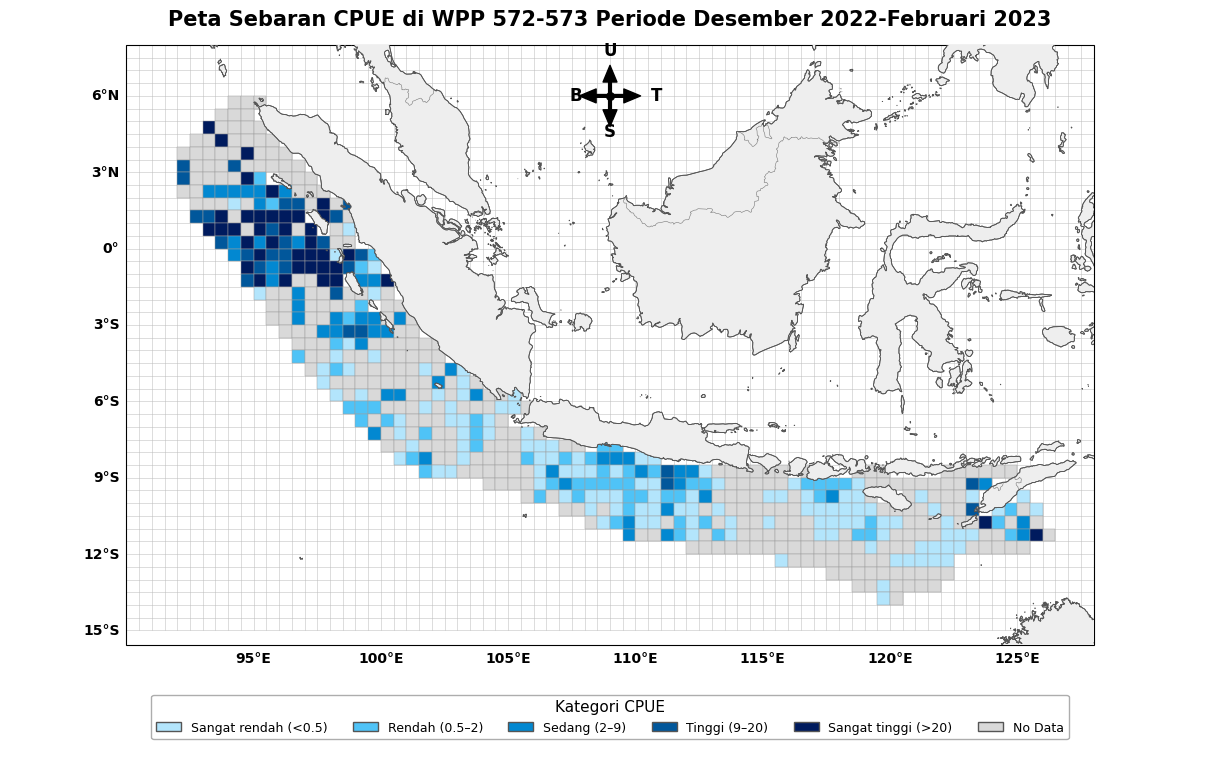

In [ ]:
# =========================
# 1. PARAMETER
# =========================
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = cpue_des2.copy()

plot_data['cpue_new'] = pd.to_numeric(
    plot_data['cpue_new'],
    errors='coerce'
)

# =========================
# 2. KATEGORI CPUE + NO DATA
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

plot_data['kategori_cpue'] = pd.cut(
    plot_data['cpue_new'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .cat.add_categories(['No Data'])
)

plot_data['kategori_cpue'] = (
    plot_data['kategori_cpue']
    .fillna('No Data')
)

# =========================
# 3. WARNA
# =========================
colors_cpue = {
    'Sangat rendah (<0.5)': '#B3E5FC',
    'Rendah (0.5–2)': '#4FC3F7',
    'Sedang (2–9)': '#0288D1',
    'Tinggi (9–20)': '#01579B',
    'Sangat tinggi (>20)': '#001B5E',
    'No Data': '#d9d9d9'
}

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.10, 0.02, 0.80, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    kategori = row['kategori_cpue']

    if pd.isna(lon) or pd.isna(lat):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=colors_cpue[kategori],
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 10,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 10,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[label],
        edgecolor='#555555',
        label=label
    )
    for label in colors_cpue
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=6,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peta Sebaran CPUE di WPP 572-573 Periode Desember 2022-Februari 2023',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

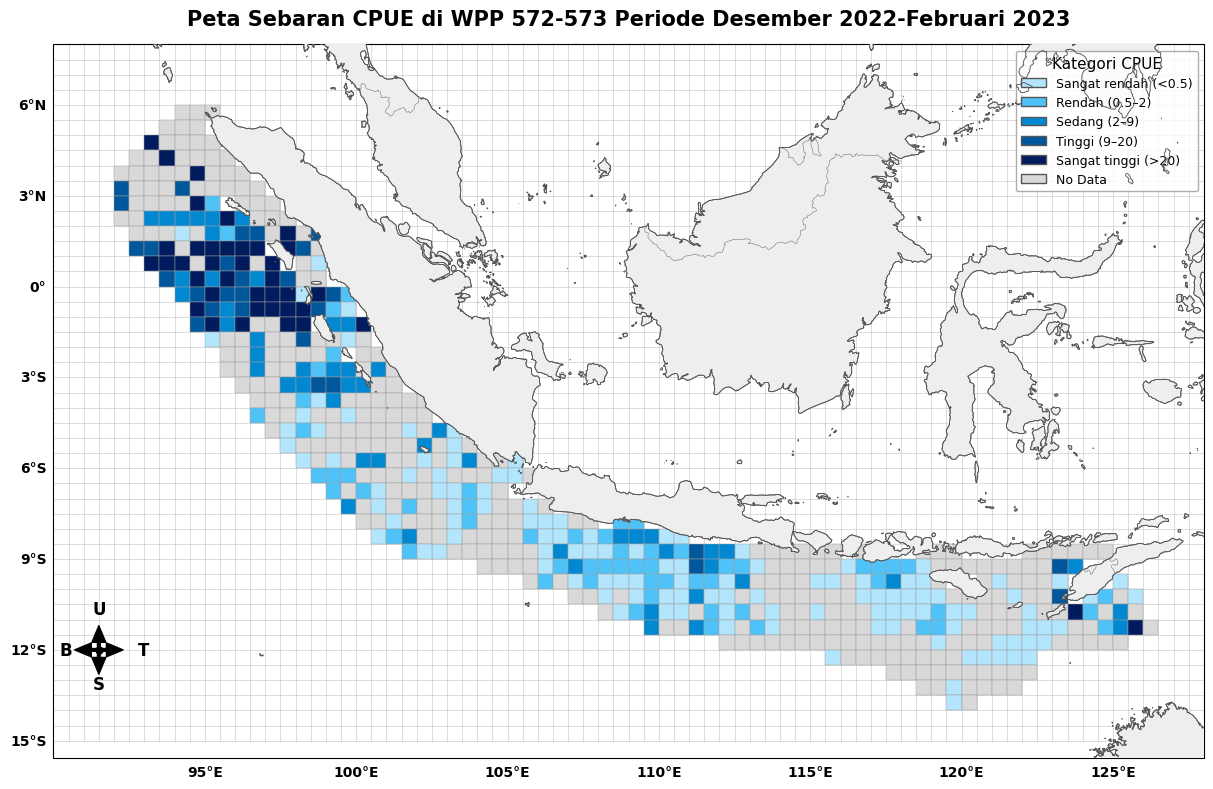

In [ ]:
# =========================
# 1. PARAMETER
# =========================
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = cpue_des2.copy()
plot_data['cpue_new'] = pd.to_numeric(plot_data['cpue_new'], errors='coerce')

# =========================
# 2. KATEGORI CPUE + NO DATA
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

plot_data['kategori_cpue'] = pd.cut(
    plot_data['cpue_new'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

plot_data['kategori_cpue'] = plot_data['kategori_cpue'].cat.add_categories(['No Data'])
plot_data['kategori_cpue'] = plot_data['kategori_cpue'].fillna('No Data')

# =========================
# 3. WARNA
# =========================
colors_cpue = {
    'Sangat rendah (<0.5)': '#B3E5FC',
    'Rendah (0.5–2)': '#4FC3F7',
    'Sedang (2–9)': '#0288D1',
    'Tinggi (9–20)': '#01579B',
    'Sangat tinggi (>20)': '#001B5E',
    'No Data': '#d9d9d9'   # abu-abu samar
}

# =========================
# 4. PLOT PETA
# =========================
fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# Grid 0.5 derajat
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot(
        [lon, lon], [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot(
        [lon_min, lon_max], [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# Plot kotak/grid CPUE
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    kategori = row['kategori_cpue']

    if pd.isna(lon) or pd.isna(lat):
        continue

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    rect = patches.Rectangle(
        (lon - grid_size / 2, lat - grid_size / 2),
        grid_size,
        grid_size,
        facecolor=colors_cpue[kategori],
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# Daratan
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.6, edgecolor='#555555', zorder=6)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linewidth=0.4, edgecolor='#777777', zorder=6)

# Label koordinat
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Legend
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[label],
        edgecolor='#555555',
        label=label
    )
    for label in colors_cpue
]

ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='upper right',
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 5. MATA ANGIN
# =========================
x_c, y_c = 91.5, -12
panjang = 0.8

ax.scatter(
    x_c, y_c,
    color='black',
    s=25,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# U
ax.annotate('', xy=(x_c, y_c + panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c + panjang + 0.4, 'U',
        ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# S
ax.annotate('', xy=(x_c, y_c - panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c - panjang - 0.5, 'S',
        ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# T
ax.annotate('', xy=(x_c + panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c + panjang + 0.5, y_c, 'T',
        va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# B
ax.annotate('', xy=(x_c - panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c - panjang - 0.5, y_c, 'B',
        va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# =========================
# 6. JUDUL
# =========================
ax.set_title(
    'Peta Sebaran CPUE di WPP 572-573 Periode Desember 2022-Februari 2023',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.tight_layout()
plt.show()

In [ ]:
np.random.seed(420)
# Definisikan koordinat dari DataFrame 'data'
coords_cpue_new = list(zip(data['Longitude'], data['Latitude']))

# Buat matriks bobot spasial K-nearest neighbors (misalnya, k=5)
w_cpue_new = KNN.from_array(coords_cpue_new, k=5)

# Standardisasi baris matriks bobot
w_cpue_new.transform = 'R'

# Hitung Moran's I untuk cpue_new
mi_cpue_new = Moran(data['cpue_new'], w_cpue_new)

print("Moran's I (cpue_new):", mi_cpue_new.I)
print("p-value (cpue_new)  :", mi_cpue_new.p_sim)
print("z-score (cpue_new)  :", mi_cpue_new.z_sim)

Moran's I (cpue_new): 0.4918139320201642
p-value (cpue_new)  : 0.001
z-score (cpue_new)  : 14.423005910337086


## Eksplorasi Boxplot

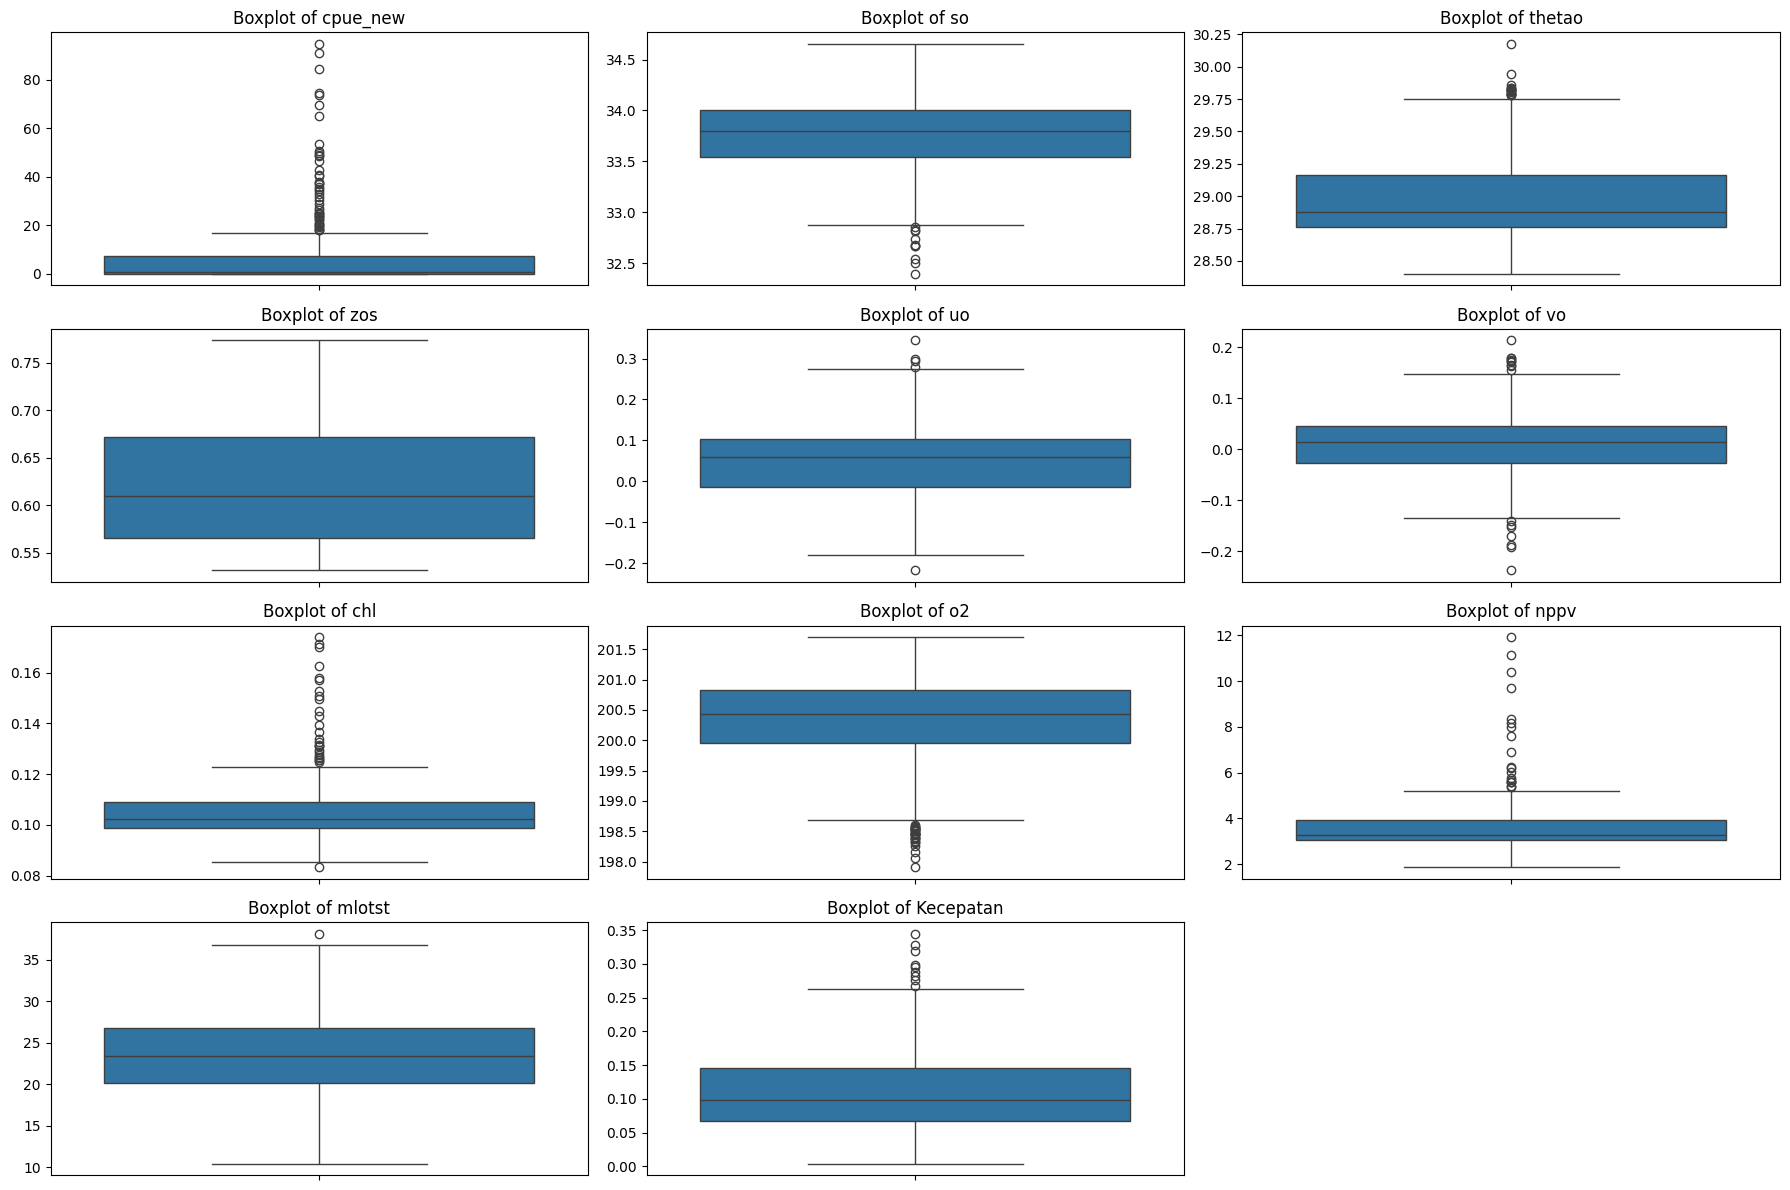

In [ ]:
columns_to_plot = ['cpue_new', 'so', 'thetao', 'zos', 'uo', 'vo', 'chl', 'o2',  'nppv', 'mlotst', 'Kecepatan']

plt.figure(figsize=(18, 12))
for i, col in enumerate(columns_to_plot):
    plt.subplot(4, 3, i + 1) # Arrange plots in a 3x3 grid
    sns.boxplot(y=data[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel('') # Remove y-axis label to avoid clutter
plt.tight_layout()
plt.show()

## Pemodelan Regresi Linear Berganda

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']

# Add a constant (intercept) to the independent variables
X = sm.add_constant(X)
VarNames = X.columns[:]

In [ ]:
# Model regresi
model = sm.OLS(y, X).fit()

# Ringkasan hasil
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               cpue_new   R-squared:                       0.293
Model:                            OLS   Adj. R-squared:                  0.271
Method:                 Least Squares   F-statistic:                     13.36
Date:                Tue, 05 May 2026   Prob (F-statistic):           6.86e-18
Time:                        08:25:52   Log-Likelihood:                -1196.9
No. Observations:                 300   AIC:                             2414.
Df Residuals:                     290   BIC:                             2451.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2050.8755    497.500     -4.122      0.0

In [ ]:
# pastikan X punya konstanta
X_const = sm.add_constant(X, has_constant="add")

# model regresi
model = sm.OLS(y, X_const).fit()

# residual
residual = model.resid

# Breusch-Pagan
bp_test = het_breuschpagan(residual, X_const)

print("Breusch-Pagan Test")
print("LM Statistic:", bp_test[0])
print("LM p-value:", bp_test[1])
print("F Statistic:", bp_test[2])
print("F p-value:", bp_test[3])

if bp_test[1] < 0.05:
    print("Terdapat heteroskedastisitas")
else:
    print("Tidak terdapat heteroskedastisitas")

Breusch-Pagan Test
LM Statistic: 25.35682594894172
LM p-value: 0.004708652406349889
F Statistic: 2.9749629984436248
F p-value: 0.0021088992571897404
Terdapat heteroskedastisitas


In [ ]:
# residual/sisaan dari model OLS
residual = model.resid

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I residual
moran_resid = Moran(residual, w)

print("Moran's I:", moran_resid.I)
print("Expected I:", moran_resid.EI)
print("p-value:", moran_resid.p_sim)
print("z-score:", moran_resid.z_sim)

if moran_resid.p_sim < 0.05:
    print("Terdapat autokorelasi spasial pada sisaan")
else:
    print("Tidak terdapat autokorelasi spasial pada sisaan")

Moran's I: 0.2842920800437303
Expected I: -0.0033444816053511705
p-value: 0.001
z-score: 8.505218738453602
Terdapat autokorelasi spasial pada sisaan


## XGBoost Global (Tanpa Longitude/Latitude)

### Pemodelan XGBoost Transformasi Log

#### Pembagian data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    210.000000
mean       7.841000
std       16.116801
min        0.000498
25%        0.123290
50%        0.927168
75%        7.312369
max       94.810576
Name: cpue_new, dtype: float64

TEST
count    90.000000
mean      7.555464
std      14.321435
min       0.001374
25%       0.120588
50%       1.195141
75%       6.543530
max      73.891342
Name: cpue_new, dtype: float64


In [ ]:
# 3. Transformasi (SETELAH split)
y_train = np.log1p(y_train)
y_test  = np.log1p(y_test)

#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:squarederror',

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100, 125]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3, 4]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05, 0.1]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha', [0.1, 0.3, 0.5, 1]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]
        ),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    # 🔥 BINNING target untuk stratification
    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    # 🔥 Stratified K-Fold
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring= 'neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),  # <- ini kuncinya
        n_jobs=1
    )

    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-05-10 13:24:52,795] A new study created in memory with name: no-name-d55cce68-8d0d-4654-9eba-8eca111ee580
[I 2026-05-10 13:24:53,055] Trial 0 finished with value: 1.0438152394620395 and parameters: {'n_estimators': 75, 'max_depth': 2, 'learning_rate': 0.01, 'subsample': 0.6, 'colsample_bytree': 0.8, 'gamma': 0.5, 'reg_alpha': 1, 'reg_lambda': 3, 'min_child_weight': 13}. Best is trial 0 with value: 1.0438152394620395.
[I 2026-05-10 13:24:53,324] Trial 1 finished with value: 0.9224119185455029 and parameters: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.05, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.1, 'reg_alpha': 1, 'reg_lambda': 3, 'min_child_weight': 13}. Best is trial 1 with value: 0.9224119185455029.
[I 2026-05-10 13:24:53,757] Trial 2 finished with value: 0.9059792642292737 and parameters: {'n_estimators': 75, 'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.7, 'colsample_bytree': 0.8, 'gamma': 0.5, 'reg_alpha': 0.5, 'reg_lambda': 1, 'min_child_w

In [ ]:
best_params = study.best_params
best_params

{'n_estimators': 75,
 'max_depth': 4,
 'learning_rate': 0.05,
 'subsample': 0.6,
 'colsample_bytree': 0.8,
 'gamma': 0.3,
 'reg_alpha': 0.1,
 'reg_lambda': 1,
 'min_child_weight': 7}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=7, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=75,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_train_log = best_model.predict(X_train)
y_pred_test_log = best_model.predict(X_test)

# inverse transform
y_pred_train = np.expm1(y_pred_train_log)
y_pred_test = np.expm1(y_pred_test_log)

# target asli
y_train_asli = np.expm1(y_train)
y_test_asli = np.expm1(y_test)

#### Evaluasi Model

In [ ]:
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return mae, rmse

# Train
mae_train, rmse_train = evaluate(y_train_asli, y_pred_train)

# Test
mae_test, rmse_test = evaluate(y_test_asli, y_pred_test)

print("=== TRAIN ===")
print("MAE:", mae_train)
print("RMSE:", rmse_train)

print("\n=== TEST ===")
print("MAE:", mae_test)
print("RMSE:", rmse_test)

=== TRAIN ===
MAE: 4.312950395731895
RMSE: 11.019989674862376

=== TEST ===
MAE: 5.460101861794159
RMSE: 12.304455447448378


In [ ]:
y_pred = best_model.predict(X)
residual = y - y_pred

from libpysal.weights import KNN

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
np.random.seed(42)
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.12966390996737928
p-value   : 0.004
z-score   : 3.87764379798738


### Pemodelan XGBoost Tweedie

#### Pembagian Data

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
# 1. Stratified binning (pakai y asli)
y_binned = pd.qcut(y, q=5, labels=False)

# 2. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y_binned, test_size=0.3, random_state=42
)

In [ ]:
print("TRAIN")
print(pd.Series(y_train).describe())

print("\nTEST")
print(pd.Series(y_test).describe())

TRAIN
count    210.000000
mean       7.841000
std       16.116801
min        0.000498
25%        0.123290
50%        0.927168
75%        7.312369
max       94.810576
Name: cpue_new, dtype: float64

TEST
count    90.000000
mean      7.555464
std      14.321435
min       0.001374
25%       0.120588
50%       1.195141
75%       6.543530
max      73.891342
Name: cpue_new, dtype: float64


#### Optuna Tuning Hyperparameter

In [ ]:
def objective(trial):

    params = {
        'objective': 'reg:tweedie',
        'eval_metric': 'rmse',

        # Tweedie power umumnya 1 < p < 2
        # p mendekati 1: mirip Poisson
        # p mendekati 2: mirip Gamma
        'tweedie_variance_power': trial.suggest_float(
            'tweedie_variance_power', 1, 2
        ),

        'n_estimators': trial.suggest_categorical(
            'n_estimators', [50, 75, 100, 125]
        ),

        'max_depth': trial.suggest_categorical(
            'max_depth', [2, 3, 4]
        ),

        'learning_rate': trial.suggest_categorical(
            'learning_rate', [0.01, 0.03, 0.05, 0.1]
        ),

        'subsample': trial.suggest_categorical(
            'subsample', [0.6, 0.7, 0.8, 0.9]
        ),

        'colsample_bytree': trial.suggest_categorical(
            'colsample_bytree', [0.6, 0.7, 0.8]
        ),

        'gamma': trial.suggest_categorical(
            'gamma', [0.1, 0.3, 0.5, 1]
        ),

        'reg_alpha': trial.suggest_categorical(
            'reg_alpha', [0.1, 0.3, 0.5, 1]
        ),

        'reg_lambda': trial.suggest_categorical(
            'reg_lambda', [1, 2, 3, 5]
        ),

        'min_child_weight': trial.suggest_categorical(
            'min_child_weight', [5, 7, 10, 13]
        ),

        'random_state': 42,
        'n_jobs': 1
    }

    model = XGBRegressor(**params)

    y_binned = pd.qcut(y_train, q=5, labels=False, duplicates='drop')

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv.split(X_train, y_binned),
        n_jobs=1
    )

    return -scores.mean()

In [ ]:
study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)

study.optimize(objective, n_trials=100)

[I 2026-05-05 08:30:44,764] A new study created in memory with name: no-name-02b20caa-d914-48f9-8d9a-9cc28a893004
[I 2026-05-05 08:30:45,053] Trial 0 finished with value: 12.665543185432796 and parameters: {'tweedie_variance_power': 1.39963209507789, 'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.1, 'subsample': 0.6, 'colsample_bytree': 0.7, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 5, 'min_child_weight': 13}. Best is trial 0 with value: 12.665543185432796.
[I 2026-05-05 08:30:45,418] Trial 1 finished with value: 13.497131601151239 and parameters: {'tweedie_variance_power': 1.7467178784931687, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01, 'subsample': 0.9, 'colsample_bytree': 0.7, 'gamma': 0.3, 'reg_alpha': 0.5, 'reg_lambda': 1, 'min_child_weight': 13}. Best is trial 0 with value: 12.665543185432796.
[I 2026-05-05 08:30:45,760] Trial 2 finished with value: 12.924095398171584 and parameters: {'tweedie_variance_power': 1.7177958154373258, 'n_estimators': 100, 'm

In [ ]:
best_params = study.best_params
best_params

{'tweedie_variance_power': 1.6055622049705767,
 'n_estimators': 75,
 'max_depth': 2,
 'learning_rate': 0.1,
 'subsample': 0.6,
 'colsample_bytree': 0.6,
 'gamma': 0.3,
 'reg_alpha': 0.5,
 'reg_lambda': 5,
 'min_child_weight': 10}

In [ ]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:tweedie',
    eval_metric='rmse',
    random_state=42
)

best_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.3, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=2,
             max_leaves=None, min_child_weight=10, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=75,
             n_jobs=None, num_parallel_tree=None, ...)

#### Evaluasi Model

In [ ]:
# Prediksi
y_train_pred = best_model.predict(X_train)
y_test_pred  = best_model.predict(X_test)

# Evaluasi train
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae  = mean_absolute_error(y_train, y_train_pred)
train_r2   = r2_score(y_train, y_train_pred)

# Evaluasi test
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae  = mean_absolute_error(y_test, y_test_pred)
test_r2   = r2_score(y_test, y_test_pred)

print("=== TRAIN EVALUATION ===")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")

print("\n=== TEST EVALUATION ===")
print(f"RMSE : {test_rmse:.4f}")
print(f"MAE  : {test_mae:.4f}")

=== TRAIN EVALUATION ===
RMSE : 9.0172
MAE  : 4.1300

=== TEST EVALUATION ===
RMSE : 12.1397
MAE  : 5.5799


#### Pengecekan Autokorelasi Spasial Residual

In [ ]:
residual2 = y - y_pred

coords = list(zip(data['Longitude'], data['Latitude']))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

In [ ]:
np.random.seed(42)
mi = Moran(residual2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.1435041112688423
p-value   : 0.002
z-score   : 4.268640860296344


## XGBoost Lokal Transformasi Logaritma

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',              # 'Adaptive' / 'Fixed'
    KernelFunction='Bisquare',      # 'Bisquare' / 'Gaussian'
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost:
    - Adaptive : Grid Search
    - Fixed    : Golden Section Ratio

    Kriteria bandwidth terbaik:
    - MAE CV terkecil pada skala asli

    Training model:
    - tetap menggunakan y_log = log1p(y)

    Evaluasi hasil terbaik:
    - ditampilkan pada skala asli dan skala log
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import (
        r2_score, mean_absolute_error, mean_squared_error
    )
    from xgboost import XGBRegressor

    # =========================================================
    # Helper RMSE
    # =========================================================
    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi & casting
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 karena fungsi ini memakai log1p(y).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    y_log = pd.Series(np.log1p(y), name='y_log')

    # =========================================================
    # Param grid model (masih bisa Anda perluas)
    # =========================================================
    reg_alpha_list = [params.get('reg_alpha', 0)]
    param_grid = {'reg_alpha': reg_alpha_list}

    # =========================================================
    # Scoring CV
    # refit = MAE asli terkecil
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -mean_absolute_error(y_true_original, y_pred_original)

    def scorer_neg_rmse_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return -rmse_func(y_true_original, y_pred_original)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_true_original = np.expm1(np.asarray(y_val_log))
        y_pred_original = np.expm1(np.asarray(y_pred_log))
        y_pred_original = np.clip(y_pred_original, a_min=0, a_max=None)
        return r2_score(y_true_original, y_pred_original)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Selection rule : minimum CV-MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)
        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")
    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)
        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot kernel
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    # =========================================================
    # Format cache key
    # =========================================================
    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi 1 bandwidth
    # MAE dipakai sebagai objective pemilihan bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        import numpy as np
        import pandas as pd

        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                result = {
                    'BW': b_eval,

                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,

                    'R2_log': np.nan,
                    'MAE_log': np.nan,
                    'RMSE_log': np.nan,

                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
                print(f"bw={b_eval:.6f}, CV_MAE=inf")
                return result
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        yt_log_true = []

        LM_yOOB_log = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []
        LM_ResOOB_log = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, y_log, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat (OOB)
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -3])
            YcentralOOB_log = float(DataSorted.iloc[0, -2])

            # ============================================
            # Pembentukan data lokal
            # ============================================
            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(LocalData['Distance'].max())

            else:  # Fixed
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits pada lokasi ke-{i}"
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-3]
            LocalY_log = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)
            kfold = KFold(n_splits=n_splits, shuffle=True, random_state=7)

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if not spatial_weights:
                    grid_result = grid_search.fit(LocalX, LocalY_log)
                else:
                    grid_result = grid_search.fit(LocalX, LocalY_log, sample_weight=SpatialWeights)

                best_model = grid_result.best_estimator_

                yOOB_log = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = float(np.expm1(yOOB_log))
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            LM_yOOB_log.append(yOOB_log)
            LM_yOOB_asli.append(yOOB_asli)

            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)
            LM_ResOOB_log.append(YcentralOOB_log - yOOB_log)

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            yt_log_true.append(YcentralOOB_log)

        if failed_reason is not None:
            result = {
                'BW': b_eval,

                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,

                'R2_log': np.nan,
                'MAE_log': np.nan,
                'RMSE_log': np.nan,

                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }
            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'y_log': yt_log_true,
            'LM_yOOB_log': LM_yOOB_log,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli,
            'LM_ResOOB_log': LM_ResOOB_log
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        y_true_log = LMResults['y_log']
        y_pred_log = LMResults['LM_yOOB_log']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        R2_log = r2_score(y_true_log, y_pred_log)
        MAE_log = mean_absolute_error(y_true_log, y_pred_log)
        RMSE_log = rmse_func(y_true_log, y_pred_log)

        # Objective utama pemilihan bandwidth
        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,

            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,

            'R2_log': R2_log,
            'MAE_log': MAE_log,
            'RMSE_log': RMSE_log,

            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result
        print(f"bw={bw_label}, CV_MAE={CV_MAE:.6f}, MAE_log={MAE_log:.6f}")
        return result

    # =========================================================
    # OPTIMASI ADAPTIVE = GRID SEARCH
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")
        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # OPTIMASI FIXED = GOLDEN SECTION RATIO
    # Objective: minimum CV_MAE
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")
        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        # Refinement akhir
        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Hasil semua bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],

            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],

            'R2_log': v['R2_log'],
            'MAE_log': v['MAE_log'],
            'RMSE_log': v['RMSE_log'],

            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = BW_results.replace([np.inf, -np.inf], np.nan).dropna(subset=['CV_MAE'])

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")
    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE (asli)    : {CV_MAE_min:.6f}")
    print(f"R2 terbaik (asli)     : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik (asli)    : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik (asli)   : {best_result['RMSE_asli']:.6f}")
    print(f"R2 terbaik (log)      : {best_result['R2_log']:.6f}")
    print(f"MAE terbaik (log)     : {best_result['MAE_log']:.6f}")
    print(f"RMSE terbaik (log)    : {best_result['RMSE_log']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results.csv'
        lm_path = 'LMResults_best_bw.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw.csv')

    BW_results.to_csv(bw_path, index=False)
    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params = {
        "n_estimators": 75,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.6,
        "colsample_bytree": 0.8,
        "objective": "reg:squarederror",
        'gamma': 0.3,
        'reg_alpha': 0.1,
        'reg_lambda': 1,
        'min_child_weight': 7,
        "random_state": 42
    }

#### Adaptive Bisquare

In [ ]:
BW_opt, BW_results, best_LMResults = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.409563, MAE_log=0.576300
bw=52, CV_MAE=5.411975, MAE_log=0.575419
bw=54, CV_MAE=5.396002, MAE_log=0.576423
bw=56, CV_MAE=5.401260, MAE_log=0.579324
bw=58, CV_MAE=5.425929, MAE_log=0.581901
bw=60, CV_MAE=5.417114, MAE_log=0.586753
bw=62, CV_MAE=5.413584, MAE_log=0.589527
bw=64, CV_MAE=5.474790, MAE_log=0.595972
bw=66, CV_MAE=5.432309, MAE_log=0.593904
bw=68, CV_MAE=5.374859, MAE_log=0.594789
bw=70, CV_MAE=5.351398, MAE_log=0.594573
bw=72, CV_MAE=5.340170, MAE_log=0.595573
bw=74, CV_MAE=5.367313, MAE_log=0.598615
bw=76, CV_MAE=5.374565, MAE_log=0.598270
bw=78, CV_MAE=5.414666, MAE_log=0.600837
bw=80, CV_MAE=5.416375, MAE_log=0.601169
bw=82, CV_MAE=5.401898, MAE_log=0.602155
bw=84, CV_MAE=5.423039, MAE_log=0.602132
bw=86, CV_MAE=5.437543, MAE_log=0.604

#### Adaptive Gaussian

In [ ]:
BW_opt2, BW_results2, best_LMResults2 = optimize_bw_gw_xgboost(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Selection rule : minimum CV-MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.315830, MAE_log=0.601492
bw=52, CV_MAE=5.365514, MAE_log=0.601364
bw=54, CV_MAE=5.446201, MAE_log=0.606099
bw=56, CV_MAE=5.438401, MAE_log=0.606510
bw=58, CV_MAE=5.414546, MAE_log=0.608389
bw=60, CV_MAE=5.394304, MAE_log=0.604738
bw=62, CV_MAE=5.403737, MAE_log=0.609811
bw=64, CV_MAE=5.384183, MAE_log=0.608187
bw=66, CV_MAE=5.435421, MAE_log=0.609351
bw=68, CV_MAE=5.364138, MAE_log=0.601563
bw=70, CV_MAE=5.394506, MAE_log=0.603367
bw=72, CV_MAE=5.385428, MAE_log=0.601330
bw=74, CV_MAE=5.376446, MAE_log=0.599427
bw=76, CV_MAE=5.483106, MAE_log=0.604834
bw=78, CV_MAE=5.381480, MAE_log=0.598153
bw=80, CV_MAE=5.363897, MAE_log=0.600174
bw=82, CV_MAE=5.407407, MAE_log=0.602283
bw=84, CV_MAE=5.397646, MAE_log=0.607466
bw=86, CV_MAE=5.338786, MAE_log=0.604

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk transformasi log(y + 1).")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Transformasi y
    # ======================================================
    y_log = pd.Series(np.log1p(y), name='y_log').reset_index(drop=True)

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Scoring CV lokal pada skala asli
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val_log):
        y_pred_log = estimator.predict(X_val)
        y_pred = np.expm1(y_pred_log)
        y_pred = np.clip(y_pred, 0, None)

        y_val = np.expm1(y_val_log)
        y_val = np.clip(y_val, 0, None)

        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': scorer_r2_original
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Log-Squarederror =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, y_log, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-3]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0]['y_asli'])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalXFull = LocalDataFull.iloc[:, :-3]
        LocalYFull_log = LocalDataFull['y_log']

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # Training pakai log(y + 1)
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        bestLocalModel.append(local_model)

        LM_yOOB_log = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = float(np.expm1(LM_yOOB_log))
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # Evaluasi dikembalikan ke skala asli
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY_log,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY_log,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # Training pakai log(y + 1)
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull_log,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull_log)

        LM_yPred_log = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = float(np.expm1(LM_yPred_log))
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Training pakai log(y + 1)
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global_log = y_log.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global_log)

        yGhat_log = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = float(np.expm1(yGhat_log))
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # Semua komponen sudah pada skala asli
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Evaluasi keseluruhan data pada skala asli
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Log-Squarederror - Pred',
            'Local XGBoost Log-Squarederror - OOB',
            'Global XGBoost Log-Squarederror - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_LogSquarederror.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_LogSquarederror.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'bestLocalModel': bestLocalModel,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=72,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 300
Calculating local model 2 of 300
Calculating local model 3 of 300
Calculating local model 4 of 300
Calculating local model 5 of 300
Calculating local model 6 of 300
Calculating local model 7 of 300
Calculating local model 8 of 300
Calculating local model 9 of 300
Calculating local model 10 of 300
Calculating local model 11 of 300
Calculating local model 12 of 300
Calculating local model 13 of 300
Calculating local model 14 of 300
Calculating local model 15 of 300
Calculating local model 16 of 300
Calculating local model 17 of 300
Calculating local model 18 of 300
Calculating local model 19 of 300
Calculating local model 20 of 300
Calculating local model 21 of 300
Calculating local model 22 of 300
Calculating local model 23 of 300
Calculating local model 24 of 300
Calculating local model 25 of 300
Calculating local model 26 of 300
Calculating local model 27 of 300
Calculating l

In [ ]:
LMResults = output_model['Prediction']
Evaluation_Results = output_model['Evaluation']

LMResults.head(300)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,18.318995,11.235165,7.598491,10.720504,-0.224821,16.617030,24.116351,0.5,12.365954,...,mlotst,0.084201,0.093276,0.115743,0.121435,0.083165,0.156506,0.095996,0.166123,0.083554
1,1,15.934011,13.264609,7.721066,8.212945,-0.335715,16.897499,24.382944,0.5,11.853088,...,uo,0.069494,0.080565,0.119061,0.149686,0.081233,0.118078,0.120512,0.144624,0.116746
2,2,9.870458,10.891237,17.198710,-7.328253,-0.305604,17.964768,25.007454,0.5,10.570254,...,mlotst,0.081686,0.080024,0.131136,0.113480,0.114367,0.112854,0.101040,0.151784,0.113630
3,3,30.287245,22.007969,18.993016,11.294229,-0.217901,16.783580,24.656292,1.0,9.912821,...,uo,0.071685,0.080572,0.089989,0.185500,0.104020,0.118188,0.064850,0.142874,0.142321
4,4,18.029441,18.012510,15.209606,2.819836,-0.170781,16.857335,23.912653,1.0,14.637561,...,nppv,0.079227,0.088092,0.137369,0.134258,0.099598,0.103101,0.081670,0.136284,0.140401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,4.129491,3.955853,3.607398,0.522093,-0.231424,2.378511,6.046877,0.5,3.940580,...,thetao,0.116445,0.191009,0.047396,0.130411,0.100005,0.100144,0.140303,0.095929,0.078358
296,296,5.518971,2.936267,2.618978,2.899993,-0.036929,2.304917,6.431792,1.0,0.795846,...,vo,0.081491,0.150582,0.066613,0.103413,0.153057,0.134694,0.149653,0.075764,0.084734
297,297,0.036587,0.153657,0.369329,-0.332742,-0.054856,2.458706,6.523205,1.0,1.967159,...,thetao,0.079645,0.161545,0.063656,0.143966,0.099278,0.084840,0.129466,0.129527,0.108077
298,298,48.590695,7.953013,2.063701,46.526995,-0.014763,1.619187,3.772496,0.5,2.624985,...,thetao,0.087728,0.184759,0.094128,0.114965,0.099707,0.086723,0.103669,0.081276,0.147046


In [ ]:
Evaluation_Results

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.642460,3.415474,9.298492
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.341936,5.340170,12.614914
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.259320,5.711832,13.383371
3,Ensemble Local + Global,y_ensemble,0.372874,5.045265,12.314805


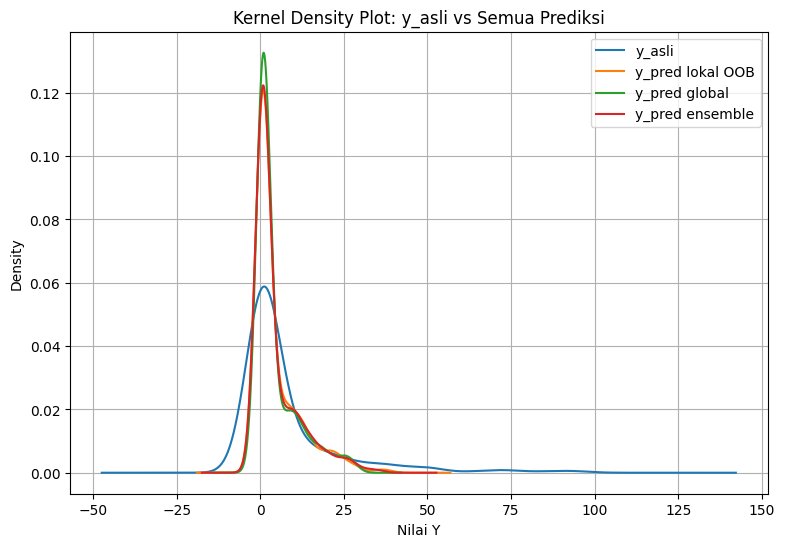

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Bisquare_Desember.xlsx")
plt.figure(figsize=(9, 6))

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults.to_excel(
    'LMResults_GWXGB_Log_Bisquare_Desember.xlsx',
    index=False
)

##### Pengecekan Autokorelasi Residual Spasial

In [ ]:
LMResults['Res_ensemble'] = (
    LMResults['y_asli'] - LMResults['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual33 = LMResults['y_asli'] - LMResults['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual33, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.19998746970836484
p-value   : 0.001
z-score   : 6.058158020646529


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual = LMResults['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.14173637252639437
p-value   : 0.002
z-score   : 4.310004826208839


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual22 = LMResults['y_asli'] - LMResults['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual22, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.1484553396050269
p-value   : 0.002
z-score   : 4.510372374502259


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk transformasi log(y + 1).")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Transformasi y training
    # ======================================================
    y_train_log = pd.Series(np.log1p(y_train), name='y_log')

    # ======================================================
    # Parameter XGBoost
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:squarederror'
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(model, feature_names, ids_new, importance_type='gain'):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [score.get(f, 0.0) for f in feature_names]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train_log)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                y_train_log,
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-3]
        LocalY_log = LocalData['y_log']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY_log,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY_log)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal untuk titik baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i.sort_values(
                by='Importance_Relative',
                ascending=False
            )
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal pada skala asli
        # ==================================================
        y_local_log = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = float(np.expm1(y_local_log))
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global pada skala asli
        # ==================================================
        y_global_log = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = float(np.expm1(y_global_log))
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_des-feb.xlsx")
prediksi.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  310 non-null    float64
 1   Latitude   310 non-null    float64
 2   periode    310 non-null    object 
 3   so         310 non-null    float64
 4   thetao     310 non-null    float64
 5   zos        310 non-null    float64
 6   uo         310 non-null    float64
 7   vo         310 non-null    float64
 8   chl        310 non-null    float64
 9   o2         310 non-null    float64
 10  mlotst     310 non-null    float64
 11  nppv       310 non-null    float64
dtypes: float64(11), object(1)
memory usage: 29.2+ KB


In [ ]:
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=72,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 310
Predicting new location 2 of 310
Predicting new location 3 of 310
Predicting new location 4 of 310
Predicting new location 5 of 310
Predicting new location 6 of 310
Predicting new location 7 of 310
Predicting new location 8 of 310
Predicting new location 9 of 310
Predicting new location 10 of 310
Predicting new location 11 of 310
Predicting new location 12 of 310
Predicting new location 13 of 310
Predicting new location 14 of 310
Predicting new location 15 of 310
Predicting new location 16 of 310
Predicting new location 17 of 310
Predicting new location 18 of 310
Predicting new location 19 of 310
Predicting new location 20 of 310
Predicting new location 21 of 310
Predicting new location 22 of 310
Predicting new location 23 of 310
Predicting new location 24 of 310
Predicting new location 25 of 310
Predicting new location 26 of 310
Predicting new location 27 of 310
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,135,0.500000,0.367970,0.986708,varying,nearest_train_id_135,1.0,0.0,0.367970,"thetao, uo, o2, so, vo"
1,1,135,0.500000,0.478713,0.388965,varying,nearest_train_id_135,1.0,0.0,0.478713,"so, thetao, vo, nppv, zos"
2,2,135,0.707107,0.339053,0.366435,varying,nearest_train_id_135,1.0,0.0,0.339053,"so, chl, o2, uo, vo"
3,3,142,0.500000,0.518192,0.660474,varying,nearest_train_id_142,0.5,0.5,0.589333,"nppv, chl, thetao, vo, so"
4,4,142,0.707107,0.326486,0.409974,varying,nearest_train_id_142,0.5,0.5,0.368230,"vo, chl, nppv, thetao, o2"
...,...,...,...,...,...,...,...,...,...,...,...
305,305,145,0.500000,0.825772,0.771483,varying,nearest_train_id_145,0.5,0.5,0.798627,"thetao, so, o2, zos, vo"
306,306,147,0.500000,0.346711,0.794994,varying,nearest_train_id_147,1.0,0.0,0.346711,"thetao, uo, zos, o2, so"
307,307,148,0.500000,0.170840,2.197364,varying,nearest_train_id_148,1.0,0.0,0.170840,"o2, so, thetao, chl, zos"
308,308,147,0.500000,0.572968,0.805780,varying,nearest_train_id_147,1.0,0.0,0.572968,"so, chl, zos, thetao, nppv"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']
prediksi['alpha_wt'] = hasil_prediksi_baru['Prediction_New']['alpha_wt']
prediksi['beta_wt'] = hasil_prediksi_baru['Prediction_New']['beta_wt']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru.xlsx',
    index=False
)

In [ ]:
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Bisquare_Desember.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model2 = build_local_gwxgboost(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_gwxgb_log_squarederror'
)

================= Building Local GWXGBoost Log-Squarederror =================
Calculating local model 1 of 300
Calculating local model 2 of 300
Calculating local model 3 of 300
Calculating local model 4 of 300
Calculating local model 5 of 300
Calculating local model 6 of 300
Calculating local model 7 of 300
Calculating local model 8 of 300
Calculating local model 9 of 300
Calculating local model 10 of 300
Calculating local model 11 of 300
Calculating local model 12 of 300
Calculating local model 13 of 300
Calculating local model 14 of 300
Calculating local model 15 of 300
Calculating local model 16 of 300
Calculating local model 17 of 300
Calculating local model 18 of 300
Calculating local model 19 of 300
Calculating local model 20 of 300
Calculating local model 21 of 300
Calculating local model 22 of 300
Calculating local model 23 of 300
Calculating local model 24 of 300
Calculating local model 25 of 300
Calculating local model 26 of 300
Calculating local model 27 of 300
Calculating l

In [ ]:
LMResults2 = output_model2['Prediction']
Evaluation_Results2 = output_model2['Evaluation']

LMResults2.head()

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,18.318995,14.863467,9.233037,9.085959,-0.118048,15.412357,22.424481,0.5,12.365954,...,mlotst,0.054500,0.078692,0.123275,0.129878,0.101283,0.142899,0.091601,0.149641,0.128230
1,1,15.934011,15.240103,10.112388,5.821623,-0.055869,15.024918,22.290107,0.5,11.853088,...,so,0.164780,0.063775,0.103762,0.139031,0.077562,0.139310,0.093782,0.104363,0.113636
2,2,9.870458,11.612898,13.081551,-3.211094,-0.373696,17.914274,25.838353,0.5,10.570254,...,zos,0.084321,0.084891,0.130839,0.113740,0.121880,0.108283,0.106471,0.129877,0.119698
3,3,30.287245,23.212584,18.622057,11.665188,-0.216415,14.477275,21.999513,1.0,9.912821,...,uo,0.092492,0.092402,0.095883,0.163157,0.117719,0.091451,0.090477,0.142262,0.114156
4,4,18.029441,20.173817,21.580870,-3.551429,-0.205218,16.221795,24.162281,0.5,14.637561,...,mlotst,0.085624,0.073060,0.126615,0.144138,0.103803,0.090602,0.085229,0.159014,0.131916


In [ ]:
Evaluation_Results2

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Log-Squarederror - Pred,LM_yPred,0.707531,3.032646,8.409885
1,Local XGBoost Log-Squarederror - OOB,LM_yOOB,0.341389,5.315830,12.620154
2,Global XGBoost Log-Squarederror - OOB,yGhat,0.259320,5.711832,13.383371
3,Ensemble Local + Global,y_ensemble,0.374122,5.009701,12.302544


<Figure size 900x600 with 0 Axes>

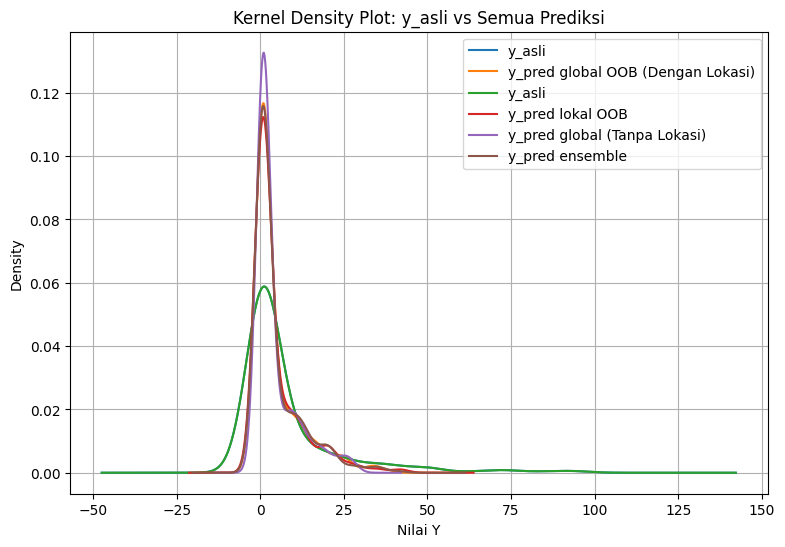

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Log_Gaussian_Desember.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_log['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

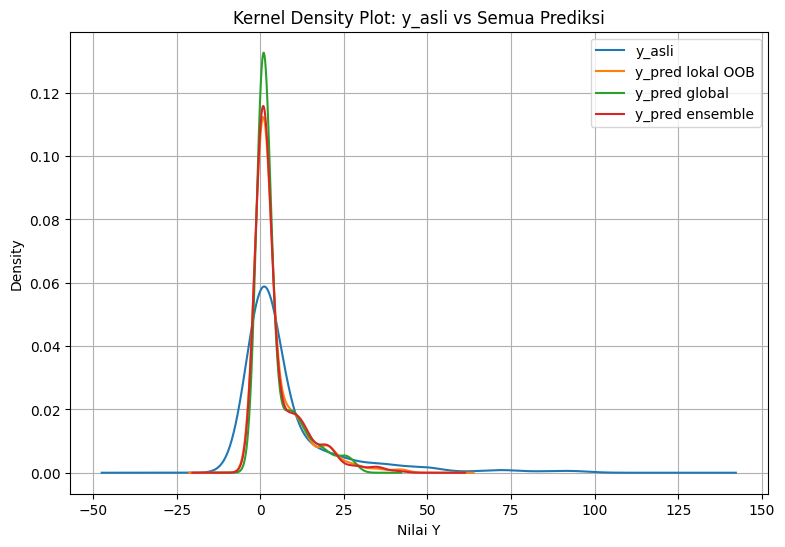

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults2['y_asli'].plot(kind='kde', label='y_asli')
LMResults2['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults2['yGhat'].plot(kind='kde', label='y_pred global')
LMResults2['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults2.to_excel(
    'LMResults_GWXGB_Log_Gaussian_Desember.xlsx',
    index=False
)

##### Pengecekan Autokorelasi

In [ ]:
LMResults2['Res_ensemble'] = (
    LMResults2['y_asli'] - LMResults2['y_ensemble']
)

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual12 = LMResults2['y_asli'] - LMResults2['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual12, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.19998746970836484
p-value   : 0.001
z-score   : 6.058158020646529


In [ ]:
## XGBoost Lokal OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual23 = LMResults2['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual23, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.10905794194166858
p-value   : 0.008
z-score   : 3.3636717902760815


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual32 = LMResults2['y_asli'] - LMResults2['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual32, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.12176546735372268
p-value   : 0.005
z-score   : 3.734936231892565


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_baru = predict_new_gwxgboost(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=50,
    params=xgb_params,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model2['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost =================
Predicting new location 1 of 310
Predicting new location 2 of 310
Predicting new location 3 of 310
Predicting new location 4 of 310
Predicting new location 5 of 310
Predicting new location 6 of 310
Predicting new location 7 of 310
Predicting new location 8 of 310
Predicting new location 9 of 310
Predicting new location 10 of 310
Predicting new location 11 of 310
Predicting new location 12 of 310
Predicting new location 13 of 310
Predicting new location 14 of 310
Predicting new location 15 of 310
Predicting new location 16 of 310
Predicting new location 17 of 310
Predicting new location 18 of 310
Predicting new location 19 of 310
Predicting new location 20 of 310
Predicting new location 21 of 310
Predicting new location 22 of 310
Predicting new location 23 of 310
Predicting new location 24 of 310
Predicting new location 25 of 310
Predicting new location 26 of 310
Predicting new location 27 of 310
Predicting new location 28 o

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_baru['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,135,0.500000,0.291221,0.986708,varying,nearest_train_id_135,1.0,0.0,0.291221,"so, thetao, zos, o2, vo"
1,1,135,0.500000,0.340234,0.388965,varying,nearest_train_id_135,1.0,0.0,0.340234,"uo, thetao, so, nppv, vo"
2,2,135,0.707107,0.202417,0.366435,varying,nearest_train_id_135,1.0,0.0,0.202417,"uo, so, vo, chl, o2"
3,3,142,0.500000,0.476361,0.660474,varying,nearest_train_id_142,0.5,0.5,0.568417,"vo, thetao, nppv, chl, uo"
4,4,142,0.707107,0.234959,0.409974,varying,nearest_train_id_142,0.5,0.5,0.322466,"vo, mlotst, nppv, so, thetao"
...,...,...,...,...,...,...,...,...,...,...,...
305,305,145,0.500000,0.937313,0.771483,varying,nearest_train_id_145,0.5,0.5,0.854398,"uo, so, thetao, vo, nppv"
306,306,147,0.500000,0.434916,0.794994,varying,nearest_train_id_147,1.0,0.0,0.434916,"uo, thetao, so, o2, zos"
307,307,148,0.500000,0.122833,2.197364,varying,nearest_train_id_148,1.0,0.0,0.122833,"chl, so, thetao, o2, zos"
308,308,147,0.500000,0.521878,0.805780,varying,nearest_train_id_147,1.0,0.0,0.521878,"so, chl, thetao, o2, nppv"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_baru['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Gaussian_Desember.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_baru['Prediction_New']['Ensemble_Pred']
prediksi['alpha_wt_Gaussian'] = hasil_prediksi_baru['Prediction_New']['alpha_wt']
prediksi['beta_wt_Gaussian'] = hasil_prediksi_baru['Prediction_New']['beta_wt']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_baru.xlsx',
    index=False
)

## XGBoost Lokal Tweedie

### Optimasi Bandwith

In [ ]:
def optimize_bw_gw_xgboost_tweedie(
    X, y, Coords, params,
    bw_min, bw_max, step=1,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    max_iter=30,
    tol=1e-3,
    path_save=False
):
    """
    Optimasi bandwidth GWXGBoost Tweedie:
    - Y tidak ditransformasi log
    - Model lokal menggunakan objective='reg:tweedie'
    - Pemilihan bandwidth berdasarkan CV_MAE terkecil pada skala asli
    """

    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, GridSearchCV
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error
        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)
    except ImportError:
        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # =========================================================
    # Validasi data
    # =========================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    # =========================================================
    # Pastikan objective Tweedie digunakan
    # =========================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    # =========================================================
    # Param grid sederhana
    # Bisa diperluas sesuai kebutuhan
    # =========================================================
    param_grid = {
        'reg_alpha': [params.get('reg_alpha', 0)]
    }

    # =========================================================
    # Scoring CV berdasarkan skala asli
    # =========================================================
    def scorer_neg_mae_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return -rmse_func(y_val, y_pred)

    def scorer_r2_original(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, a_min=0, a_max=None)
        return r2_score(y_val, y_pred)

    scoring = {
        'neg_mean_absolute_error_original': scorer_neg_mae_original,
        'neg_root_mean_squared_error_original': scorer_neg_rmse_original,
        'r2_original': scorer_r2_original
    }

    print("================= Optimizing bandwidth =================")
    print(f"Bandwidth mode : {Kernel}")
    print(f"Kernel function: {KernelFunction}")
    print(f"Spatial weights: {spatial_weights}")
    print("Model objective: reg:tweedie")
    print(f"Tweedie variance power: {params['tweedie_variance_power']}")
    print("Selection rule : minimum CV_MAE on original scale")

    num_rows = len(X)
    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    if Kernel == 'Adaptive':
        bw_min = int(bw_min)
        bw_max = min(int(bw_max), num_rows - 1)
        step = int(step)

        if bw_min < 1:
            raise ValueError("Untuk Adaptive, bw_min minimal 1.")
        if bw_min > bw_max:
            raise ValueError("Untuk Adaptive, bw_min harus <= bw_max.")
        if step < 1:
            raise ValueError("Untuk Adaptive, step minimal 1.")

    else:
        bw_min = float(bw_min)
        bw_max = float(bw_max)

        if bw_min <= 0 or bw_max <= 0 or bw_min >= bw_max:
            raise ValueError("Untuk Fixed, pastikan 0 < bw_min < bw_max.")

    results_cache = {}

    # =========================================================
    # Bobot spasial
    # =========================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0
        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)
        else:
            raise ValueError("KernelFunction tidak dikenal.")

        return np.asarray(w, dtype=float)

    def bw_key(b):
        if Kernel == 'Adaptive':
            return int(round(b))
        else:
            return round(float(b), 10)

    # =========================================================
    # Evaluasi satu bandwidth
    # =========================================================
    def evaluate_bandwidth(b):
        if Kernel == 'Adaptive':
            b_eval = int(round(b))
            b_eval = max(int(bw_min), min(int(bw_max), b_eval))
            bw_label = f"{b_eval:d}"
        else:
            b_eval = float(b)
            if b_eval <= 0:
                return {
                    'BW': b_eval,
                    'R2_asli': np.nan,
                    'MAE_asli': np.nan,
                    'RMSE_asli': np.nan,
                    'CV_MAE': np.inf,
                    'LMResults': None,
                    'status': 'bw harus > 0'
                }
            bw_label = f"{b_eval:.6f}"

        key = bw_key(b_eval)
        if key in results_cache:
            return results_cache[key]

        listIDs = []
        yt_asli = []
        LM_yOOB_asli = []
        LM_ResOOB_asli = []

        failed_reason = None

        for i in range(num_rows):
            Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
            Neighbours.columns = ['Distance']

            Data = pd.concat([X, y, Neighbours], axis=1)
            DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

            # Titik pusat sebagai OOB
            XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
            YcentralOOB_asli = float(DataSorted.iloc[0, -2])

            if Kernel == 'Adaptive':
                knn = int(b_eval)
                LocalData = DataSorted.iloc[1:knn + 1, :].copy()

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(LocalData['Distance'].max())

            else:
                LocalData = DataSorted[DataSorted.Distance < b_eval].copy()
                LocalData = LocalData.iloc[1:, :]

                if LocalData.shape[0] < n_splits:
                    failed_reason = (
                        f"bw={b_eval:.6f} gagal: jumlah data lokal < n_splits "
                        f"pada lokasi ke-{i}"
                    )
                    break

                h = float(b_eval)

            h = max(h, 1e-12)

            LocalX = LocalData.iloc[:, :-2]
            LocalY = LocalData.iloc[:, -2]

            if spatial_weights:
                SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            else:
                SpatialWeights = None

            model = XGBRegressor(**params)

            kfold = KFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=7
            )

            grid_search = GridSearchCV(
                estimator=model,
                param_grid=param_grid,
                scoring=scoring,
                refit='neg_mean_absolute_error_original',
                return_train_score=True,
                n_jobs=-1,
                cv=kfold
            )

            try:
                if spatial_weights:
                    grid_result = grid_search.fit(
                        LocalX,
                        LocalY,
                        sample_weight=SpatialWeights
                    )
                else:
                    grid_result = grid_search.fit(LocalX, LocalY)

                best_model = grid_result.best_estimator_

                yOOB_asli = float(best_model.predict(XcentralOOB)[0])
                yOOB_asli = max(yOOB_asli, 0.0)

            except Exception as e:
                failed_reason = f"bw={bw_label} gagal pada lokasi ke-{i}: {str(e)}"
                break

            listIDs.append(i)
            yt_asli.append(YcentralOOB_asli)
            LM_yOOB_asli.append(yOOB_asli)
            LM_ResOOB_asli.append(YcentralOOB_asli - yOOB_asli)

        if failed_reason is not None:
            result = {
                'BW': b_eval,
                'R2_asli': np.nan,
                'MAE_asli': np.nan,
                'RMSE_asli': np.nan,
                'CV_MAE': np.inf,
                'LMResults': None,
                'status': failed_reason
            }

            results_cache[key] = result
            print(f"bw={bw_label}, CV_MAE=inf")
            print(f"   alasan: {failed_reason}")
            return result

        LMResults = pd.DataFrame({
            'IDS': listIDs,
            'y_asli': yt_asli,
            'LM_yOOB_asli': LM_yOOB_asli,
            'LM_ResOOB_asli': LM_ResOOB_asli
        })

        y_true_asli = LMResults['y_asli']
        y_pred_asli = LMResults['LM_yOOB_asli']

        R2_asli = r2_score(y_true_asli, y_pred_asli)
        MAE_asli = mean_absolute_error(y_true_asli, y_pred_asli)
        RMSE_asli = rmse_func(y_true_asli, y_pred_asli)

        CV_MAE = MAE_asli

        result = {
            'BW': b_eval,
            'R2_asli': R2_asli,
            'MAE_asli': MAE_asli,
            'RMSE_asli': RMSE_asli,
            'CV_MAE': CV_MAE,
            'LMResults': LMResults,
            'status': 'ok'
        }

        results_cache[key] = result

        print(
            f"bw={bw_label}, "
            f"CV_MAE={CV_MAE:.6f}, "
            f"R2={R2_asli:.6f}, "
            f"RMSE={RMSE_asli:.6f}"
        )

        return result

    # =========================================================
    # Adaptive: Grid Search
    # =========================================================
    def optimize_adaptive_grid():
        bw_candidates = list(range(int(bw_min), int(bw_max) + 1, int(step)))

        if len(bw_candidates) == 0:
            raise ValueError("Tidak ada kandidat bandwidth adaptive.")

        print("Optimization method: Grid Search (Adaptive)")

        for bw in bw_candidates:
            evaluate_bandwidth(bw)

    # =========================================================
    # Fixed: Golden Section Ratio
    # =========================================================
    def optimize_fixed_golden():
        a = float(bw_min)
        b = float(bw_max)

        phi = (1 + np.sqrt(5)) / 2
        invphi = 1 / phi

        c = b - (b - a) * invphi
        d = a + (b - a) * invphi

        fc = evaluate_bandwidth(c)['CV_MAE']
        fd = evaluate_bandwidth(d)['CV_MAE']

        iter_count = 0

        print("Optimization method: Golden Section Ratio (Fixed)")

        while abs(b - a) > tol and iter_count < max_iter:
            if fc <= fd:
                b = d
                d = c
                fd = fc
                c = b - (b - a) * invphi
                fc = evaluate_bandwidth(c)['CV_MAE']
            else:
                a = c
                c = d
                fc = fd
                d = a + (b - a) * invphi
                fd = evaluate_bandwidth(d)['CV_MAE']

            iter_count += 1
            print(f"[Golden iter {iter_count}] interval bw = [{a:.6f}, {b:.6f}]")

        mid = (a + b) / 2.0
        refine_points = np.unique([a, c, mid, d, b])

        for bw_val in refine_points:
            evaluate_bandwidth(float(bw_val))

    # =========================================================
    # Jalankan optimasi
    # =========================================================
    if Kernel == 'Adaptive':
        optimize_adaptive_grid()
    else:
        optimize_fixed_golden()

    # =========================================================
    # Rekap hasil bandwidth
    # =========================================================
    BW_results = pd.DataFrame([
        {
            'BW': v['BW'],
            'R2_asli': v['R2_asli'],
            'MAE_asli': v['MAE_asli'],
            'RMSE_asli': v['RMSE_asli'],
            'CV_MAE': v['CV_MAE'],
            'status': v['status']
        }
        for v in results_cache.values()
    ]).sort_values(by='BW').reset_index(drop=True)

    BW_results_valid = (
        BW_results
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=['CV_MAE'])
    )

    if BW_results_valid.empty:
        raise ValueError("Semua kandidat bandwidth gagal dievaluasi. Coba perbesar bandwidth.")

    idx_best = BW_results_valid['CV_MAE'].idxmin()
    BW_opt = BW_results_valid.loc[idx_best, 'BW']
    CV_MAE_min = float(BW_results_valid.loc[idx_best, 'CV_MAE'])

    if Kernel == 'Adaptive':
        BW_opt = int(round(BW_opt))
    else:
        BW_opt = float(BW_opt)

    best_result = evaluate_bandwidth(BW_opt)
    best_LMResults = best_result['LMResults']

    print("=========================================================================")

    if Kernel == 'Adaptive':
        print(f"Best bandwidth        : {BW_opt}")
    else:
        print(f"Best bandwidth        : {BW_opt:.6f}")

    print(f"Best CV_MAE           : {CV_MAE_min:.6f}")
    print(f"R2 terbaik            : {best_result['R2_asli']:.6f}")
    print(f"MAE terbaik           : {best_result['MAE_asli']:.6f}")
    print(f"RMSE terbaik          : {best_result['RMSE_asli']:.6f}")
    print("=========================================================================")

    # =========================================================
    # Simpan hasil
    # =========================================================
    if not path_save:
        bw_path = 'BW_results_tweedie.csv'
        lm_path = 'LMResults_best_bw_tweedie.csv'
    else:
        os.makedirs(path_save, exist_ok=True)
        bw_path = os.path.join(path_save, 'BW_results_tweedie.csv')
        lm_path = os.path.join(path_save, 'LMResults_best_bw_tweedie.csv')

    BW_results.to_csv(bw_path, index=False)

    if best_LMResults is not None:
        best_LMResults.to_csv(lm_path, index=False)

    return BW_opt, BW_results, best_LMResults

In [ ]:
Coords = data[['Longitude', 'Latitude']]

In [ ]:
X = data[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
y = data['cpue_new']
VarNames = X.columns[:]

In [ ]:
xgb_params2 = {
    "objective": "reg:tweedie",
    'tweedie_variance_power': 1.6055622049705767,
    "n_estimators": 75,
    "learning_rate": 0.1,
    "max_depth": 2,
    "subsample": 0.6,
    "colsample_bytree": 0.6,
    'gamma': 0.3,
    'reg_alpha': 0.5,
    'reg_lambda': 5,
    'min_child_weight': 10,
     "random_state": 42
}

#### Adaptive Bisquare

In [ ]:
BW_opt3, BW_results3, best_LMResults3 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Bisquare
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.6055622049705767
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.423243, R2=0.380117, RMSE=12.243487
bw=52, CV_MAE=5.416294, R2=0.374240, RMSE=12.301387
bw=54, CV_MAE=5.450558, R2=0.369087, RMSE=12.351932
bw=56, CV_MAE=5.452174, R2=0.360313, RMSE=12.437527
bw=58, CV_MAE=5.438111, R2=0.360373, RMSE=12.436941
bw=60, CV_MAE=5.476934, R2=0.355892, RMSE=12.480434
bw=62, CV_MAE=5.456102, R2=0.353790, RMSE=12.500780
bw=64, CV_MAE=5.426081, R2=0.359325, RMSE=12.447126
bw=66, CV_MAE=5.414228, R2=0.356310, RMSE=12.476381
bw=68, CV_MAE=5.454359, R2=0.354437, RMSE=12.494520
bw=70, CV_MAE=5.497948, R2=0.346642, RMSE=12.569722
bw=72, CV_MAE=5.563840, R2=0.343424, RMSE=12.600645
bw=74, CV_MAE=5.498255, R2=0.348008, RMSE=12.556578
bw=76, CV_MAE=5.479157, R2=

#### Adaptive Gaussian

In [ ]:
BW_opt4, BW_results4, best_LMResults4 = optimize_bw_gw_xgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    params=xgb_params2,
    bw_min=50,
    bw_max=150,
    step=2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3
)

================= Optimizing bandwidth =================
Bandwidth mode : Adaptive
Kernel function: Gaussian
Spatial weights: True
Model objective: reg:tweedie
Tweedie variance power: 1.6055622049705767
Selection rule : minimum CV_MAE on original scale
Optimization method: Grid Search (Adaptive)
bw=50, CV_MAE=5.499696, R2=0.339589, RMSE=12.637392
bw=52, CV_MAE=5.386902, R2=0.370186, RMSE=12.341172
bw=54, CV_MAE=5.500951, R2=0.347585, RMSE=12.560654
bw=56, CV_MAE=5.519685, R2=0.338892, RMSE=12.644058
bw=58, CV_MAE=5.463737, R2=0.357051, RMSE=12.469195
bw=60, CV_MAE=5.438748, R2=0.350703, RMSE=12.530601
bw=62, CV_MAE=5.498692, R2=0.347529, RMSE=12.561189
bw=64, CV_MAE=5.612987, R2=0.333794, RMSE=12.692710
bw=66, CV_MAE=5.703575, R2=0.328181, RMSE=12.746070
bw=68, CV_MAE=5.562374, R2=0.353079, RMSE=12.507652
bw=70, CV_MAE=5.520362, R2=0.356598, RMSE=12.473593
bw=72, CV_MAE=5.583475, R2=0.344995, RMSE=12.585561
bw=74, CV_MAE=5.588512, R2=0.348184, RMSE=12.554886
bw=76, CV_MAE=5.617583, R2=

### Pemodelan XGBoost Lokal

In [ ]:
def build_local_gwxgboost_tweedie(
    X, y, Coords, BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd

    from scipy.spatial import distance_matrix
    from sklearn.model_selection import KFold, cross_validate
    from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
    from xgboost import XGBRegressor

    try:
        from sklearn.metrics import root_mean_squared_error

        def rmse_func(y_true, y_pred):
            return root_mean_squared_error(y_true, y_pred)

    except ImportError:

        def rmse_func(y_true, y_pred):
            return mean_squared_error(y_true, y_pred, squared=False)

    # ======================================================
    # Validasi data
    # ======================================================
    X = pd.DataFrame(X).reset_index(drop=True).copy()
    y = pd.Series(np.ravel(y), name='y_asli').reset_index(drop=True).copy()
    Coords = pd.DataFrame(Coords).reset_index(drop=True).copy()

    if (y < 0).any():
        raise ValueError("Semua nilai y harus >= 0 untuk objective Tweedie.")

    if len(X) != len(y) or len(X) != len(Coords):
        raise ValueError("Panjang X, y, dan Coords harus sama.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    if alpha_wt < 0 or alpha_wt > 1:
        raise ValueError("alpha_wt harus berada antara 0 dan 1.")

    # ======================================================
    # Parameter Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'

    if 'tweedie_variance_power' not in params:
        params['tweedie_variance_power'] = 1.5

    params['random_state'] = random_state

    num_rows = len(X)
    feature_names = list(X.columns)

    DistanceMatrix_ij = pd.DataFrame(distance_matrix(Coords, Coords))

    # ======================================================
    # Model global penuh untuk peubah penting global
    # Berdasarkan nilai gain
    # ======================================================
    global_model_full = XGBRegressor(
        **params,
        importance_type='gain'
    )

    global_model_full.fit(X, y)

    # Ambil nilai gain dari booster
    global_gain_dict = global_model_full.get_booster().get_score(
        importance_type='gain'
    )

    # Susun semua peubah agar tetap muncul,
    # termasuk peubah yang tidak pernah dipakai split
    GlobalImportance = pd.DataFrame({
        'Feature': feature_names,
        'Gain': [
            float(global_gain_dict.get(feature, 0.0))
            for feature in feature_names
        ]
    })

    # Normalisasi gain agar lebih mudah dibaca sebagai proporsi
    total_gain = GlobalImportance['Gain'].sum()

    if total_gain > 0:
        GlobalImportance['Gain_Normalized'] = (
            GlobalImportance['Gain'] / total_gain
        )
    else:
        GlobalImportance['Gain_Normalized'] = 0.0

    GlobalImportance = GlobalImportance.sort_values(
        by='Gain',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Scoring CV lokal
    # ======================================================
    def scorer_neg_mae(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -mean_absolute_error(y_val, y_pred)

    def scorer_neg_rmse(estimator, X_val, y_val):
        y_pred = estimator.predict(X_val)
        y_pred = np.clip(y_pred, 0, None)
        return -rmse_func(y_val, y_pred)

    scoring = {
        'neg_mae': scorer_neg_mae,
        'neg_rmse': scorer_neg_rmse,
        'r2': 'r2'
    }

    # ======================================================
    # Bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    results = []
    importance_rows = []
    bestLocalModel = []

    print("================= Building Local GWXGBoost Tweedie =================")
    print("================= Global importance by gain has been calculated =================")

    # ======================================================
    # Loop model lokal
    # ======================================================
    for i in range(num_rows):

        print(f"Calculating local model {i + 1} of {num_rows}")

        Neighbours = pd.DataFrame(DistanceMatrix_ij.iloc[:, i])
        Neighbours.columns = ['Distance']

        Data = pd.concat([X, y, Neighbours], axis=1)
        DataSorted = Data.sort_values(by='Distance').reset_index(drop=True)

        XcentralOOB = pd.DataFrame(DataSorted.iloc[0, :-2]).T
        XcentralOOB.columns = X.columns

        YcentralOOB = float(DataSorted.iloc[0, -2])

        # ==================================================
        # Local data OOB dan full
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            LocalData = DataSorted.iloc[1:knn + 1, :].copy()
            LocalDataFull = DataSorted.iloc[:knn + 1, :].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataSorted[DataSorted.Distance < bw].copy()
            LocalData = LocalData.iloc[1:, :].copy()

            LocalDataFull = DataSorted[DataSorted.Distance < bw].copy()

            if LocalData.shape[0] < n_splits:
                raise ValueError(
                    f"Jumlah data lokal lokasi ke-{i} kurang dari n_splits."
                )

            h = bw

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData.iloc[:, -2]

        LocalXFull = LocalDataFull.iloc[:, :-2]
        LocalYFull = LocalDataFull.iloc[:, -2]

        LocalX.columns = X.columns
        LocalXFull.columns = X.columns

        if spatial_weights:
            SpatialWeights = calc_spatial_weights(LocalData['Distance'], h)
            SpatialWeightsFull = calc_spatial_weights(LocalDataFull['Distance'], h)
        else:
            SpatialWeights = None
            SpatialWeightsFull = None

        # ==================================================
        # Model lokal OOB
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        bestLocalModel.append(local_model)

        LM_yOOB = float(local_model.predict(XcentralOOB)[0])
        LM_yOOB = max(LM_yOOB, 0.0)

        LM_ResOOB = YcentralOOB - LM_yOOB

        # ==================================================
        # CV lokal MAE, RMSE, R2
        # ==================================================
        kfold = KFold(
            n_splits=n_splits,
            shuffle=True,
            random_state=random_state
        )

        try:
            if spatial_weights:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    params={'sample_weight': SpatialWeights},
                    n_jobs=-1
                )
            else:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        except TypeError:
            try:
                if spatial_weights:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        fit_params={'sample_weight': SpatialWeights},
                        n_jobs=-1
                    )
                else:
                    cv_result = cross_validate(
                        local_model,
                        LocalX,
                        LocalY,
                        scoring=scoring,
                        cv=kfold,
                        n_jobs=-1
                    )

            except TypeError:
                cv_result = cross_validate(
                    local_model,
                    LocalX,
                    LocalY,
                    scoring=scoring,
                    cv=kfold,
                    n_jobs=-1
                )

        LM_Best_score_MAE = -np.mean(cv_result['test_neg_mae'])
        LM_Best_score_RMSE = -np.mean(cv_result['test_neg_rmse'])
        LMRsqr = np.mean(cv_result['test_r2'])

        # ==================================================
        # Model lokal full: including central point
        # ==================================================
        local_model_full = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model_full.fit(
                LocalXFull,
                LocalYFull,
                sample_weight=SpatialWeightsFull
            )
        else:
            local_model_full.fit(LocalXFull, LocalYFull)

        LM_yPred = float(local_model_full.predict(XcentralOOB)[0])
        LM_yPred = max(LM_yPred, 0.0)

        # ==================================================
        # Model global excluding central point
        # Global OOB prediction
        # ==================================================
        X_global = X.drop(index=i).reset_index(drop=True)
        y_global = y.drop(index=i).reset_index(drop=True)

        global_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        global_model.fit(X_global, y_global)

        yGhat = float(global_model.predict(X.iloc[[i]])[0])
        yGhat = max(yGhat, 0.0)

        # ==================================================
        # Alpha ensemble mengikuti konsep GeoXGBoost
        # ==================================================
        res_local = YcentralOOB - LM_yOOB
        res_global = YcentralOOB - yGhat

        if alpha_wt_type == 'fixed':
            Alpha_wt = float(alpha_wt)

        elif alpha_wt_type == 'varying':
            if alpha_wt == 1:
                Alpha_wt = 1.0
            else:
                if abs(res_global) > abs(res_local):
                    Alpha_wt = 1.0
                else:
                    Alpha_wt = float(alpha_wt)

        beta_wt = 1 - Alpha_wt

        y_ensemble = Alpha_wt * LM_yOOB + beta_wt * yGhat
        y_ensemble = max(float(y_ensemble), 0.0)

        # ==================================================
        # Feature importance lokal
        # ==================================================
        Imp_ = local_model.feature_importances_

        imp_dict = {
            f'Imp_{feature_names[j]}': float(Imp_[j])
            for j in range(len(feature_names))
        }

        MaxImportance = float(np.max(Imp_))
        MaxFeatureID = feature_names[int(np.argmax(Imp_))]

        importance_rows.append({
            'IDS': i,
            **imp_dict
        })

        results.append({
            'IDS': i,
            'y_asli': YcentralOOB,

            'LM_yPred': LM_yPred,
            'LM_yOOB': LM_yOOB,
            'LM_ResOOB': LM_ResOOB,

            'LMRsqr': LMRsqr,
            'LM_Best_score_MAE': LM_Best_score_MAE,
            'LM_Best_score_RMSE': LM_Best_score_RMSE,

            'alpha_wt': Alpha_wt,
            'yGhat': yGhat,
            'y_ensemble': y_ensemble,

            'MaxImportance': MaxImportance,
            'MaxFeatureID': MaxFeatureID
        })

    # ======================================================
    # Gabungkan hasil lokal
    # ======================================================
    LMResults = pd.DataFrame(results)
    LocalImportance = pd.DataFrame(importance_rows)

    LMResults = LMResults.merge(
        LocalImportance,
        on='IDS',
        how='left'
    )

    # ======================================================
    # Ringkasan peubah penting lokal
    # ======================================================
    local_imp_cols = [
        col for col in LMResults.columns
        if col.startswith('Imp_')
    ]

    LocalImportanceSummary = []

    for col in local_imp_cols:
        feature = col.replace('Imp_', '')

        LocalImportanceSummary.append({
            'Feature': feature,
            'Mean_Local_Importance': LMResults[col].mean(),
            'Median_Local_Importance': LMResults[col].median(),
            'Std_Local_Importance': LMResults[col].std(),
            'Min_Local_Importance': LMResults[col].min(),
            'Max_Local_Importance': LMResults[col].max(),
            'Frequency_As_MaxFeature': (LMResults['MaxFeatureID'] == feature).sum(),
            'Proportion_As_MaxFeature': (
                (LMResults['MaxFeatureID'] == feature).sum() / len(LMResults)
            )
        })

    LocalImportanceSummary = pd.DataFrame(LocalImportanceSummary)

    LocalImportanceSummary = LocalImportanceSummary.sort_values(
        by='Mean_Local_Importance',
        ascending=False
    ).reset_index(drop=True)

    # ======================================================
    # Evaluasi keseluruhan data
    # ======================================================
    y_true = LMResults['y_asli']

    Evaluation_Results = pd.DataFrame({
        'Model': [
            'Local XGBoost Tweedie - Pred',
            'Local XGBoost Tweedie - OOB',
            'Global XGBoost Tweedie - OOB',
            'Ensemble Local + Global'
        ],
        'Kolom_Prediksi': [
            'LM_yPred',
            'LM_yOOB',
            'yGhat',
            'y_ensemble'
        ],
        'R2': [
            r2_score(y_true, LMResults['LM_yPred']),
            r2_score(y_true, LMResults['LM_yOOB']),
            r2_score(y_true, LMResults['yGhat']),
            r2_score(y_true, LMResults['y_ensemble'])
        ],
        'MAE': [
            mean_absolute_error(y_true, LMResults['LM_yPred']),
            mean_absolute_error(y_true, LMResults['LM_yOOB']),
            mean_absolute_error(y_true, LMResults['yGhat']),
            mean_absolute_error(y_true, LMResults['y_ensemble'])
        ],
        'RMSE': [
            rmse_func(y_true, LMResults['LM_yPred']),
            rmse_func(y_true, LMResults['LM_yOOB']),
            rmse_func(y_true, LMResults['yGhat']),
            rmse_func(y_true, LMResults['y_ensemble'])
        ]
    })

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        LMResults.to_csv(
            os.path.join(path_save, 'LocalModelResults_GWXGB_Tweedie.csv'),
            index=False
        )

        Evaluation_Results.to_csv(
            os.path.join(path_save, 'Evaluation_GWXGB_Tweedie.csv'),
            index=False
        )

        GlobalImportance.to_csv(
            os.path.join(path_save, 'GlobalImportance_GWXGB_Tweedie_Gain.csv'),
            index=False
        )

        LocalImportanceSummary.to_csv(
            os.path.join(path_save, 'LocalImportanceSummary_GWXGB_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction': LMResults,
        'Evaluation': Evaluation_Results,
        'GlobalImportance': GlobalImportance,
        'LocalImportanceSummary': LocalImportanceSummary,
        'bestLocalModel': bestLocalModel,
        'globalModelFull': global_model_full,
        'alpha_wt': LMResults['alpha_wt'].tolist()
    }

    return output

#### Adaptive Bisquare

In [ ]:
output_model3 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=66,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 300
Calculating local model 2 of 300
Calculating local model 3 of 300
Calculating local model 4 of 300
Calculating local model 5 of 300
Calculating local model 6 of 300
Calculating local model 7 of 300
Calculating local model 8 of 300
Calculating local model 9 of 300
Calculating local model 10 of 300
Calculating local model 11 of 300
Calculating local model 12 of 300
Calculating local model 13 of 300
Calculating local model 14 of 300
Calculating local model 15 of 300
Calculating local model 16 of 300
Calculating local model 17 of 300
Calculating local model 18 of 300
Calculating local model 19 of 300
Calculating local model 20 of 300
Calculating local model 21 of 300
Calculating local model 22 of 300
Calculating local model 23 of 300
Calculating local model 24 of 300
Calculating local model 25 of 300
Calculat

In [ ]:
LMResults3 = output_model3['Prediction']
Evaluation_Results3 = output_model3['Evaluation']

LMResults3.head(300)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,18.318995,16.618525,8.272981,10.046015,0.044398,14.811575,19.907347,0.5,21.342607,...,zos,0.025895,0.148679,0.178472,0.093960,0.098768,0.114428,0.131597,0.108195,0.100006
1,1,15.934011,13.396192,10.031337,5.902674,-0.672323,17.053602,22.502897,0.5,13.482290,...,thetao,0.064411,0.221460,0.092230,0.150672,0.104729,0.076761,0.087368,0.109231,0.093139
2,2,9.870458,13.125367,18.893568,-9.023111,-0.189733,15.535413,22.757801,0.5,6.634219,...,uo,0.083357,0.099495,0.113032,0.150375,0.115585,0.111648,0.088987,0.136267,0.101255
3,3,30.287245,27.064581,20.842287,9.444958,-0.066014,14.715806,21.215508,1.0,8.711604,...,uo,0.080271,0.110545,0.077462,0.227553,0.105570,0.102580,0.062822,0.113042,0.120155
4,4,18.029441,18.224237,18.784790,-0.755349,-0.337382,16.091073,22.509899,1.0,9.165597,...,mlotst,0.064611,0.109485,0.145444,0.122880,0.128252,0.090263,0.090271,0.149203,0.099592
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,4.129491,3.069079,2.755493,1.373999,-0.165251,3.265704,6.544087,0.5,4.142704,...,chl,0.102431,0.059229,0.108572,0.061485,0.088108,0.229807,0.147100,0.123301,0.079967
296,296,5.518971,3.367428,0.867924,4.651047,-0.303277,3.007216,6.536016,0.5,1.150057,...,mlotst,0.148791,0.096924,0.054325,0.056454,0.141873,0.110945,0.142941,0.161461,0.086285
297,297,0.036587,1.609724,3.098919,-3.062332,-0.300972,2.851270,5.613915,0.5,0.932936,...,so,0.137961,0.079498,0.100074,0.083848,0.089376,0.135886,0.117373,0.130034,0.125950
298,298,48.590695,27.093801,1.470361,47.120334,-0.049874,2.209922,4.375897,1.0,1.088990,...,mlotst,0.046938,0.082236,0.160920,0.089010,0.091168,0.091424,0.155869,0.191610,0.090824


In [ ]:
LMResults3.to_excel(
    'LMResults_GWXGB_Tweedie_Bisquare_Desember.xlsx',
    index=False
)

In [ ]:
Evaluation_Results3

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.958211,1.657015,3.178930
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.356310,5.414228,12.476381
2,Global XGBoost Tweedie - OOB,yGhat,0.335079,5.834868,12.680469
3,Ensemble Local + Global,y_ensemble,0.431433,4.854493,11.725763


<Figure size 900x600 with 0 Axes>

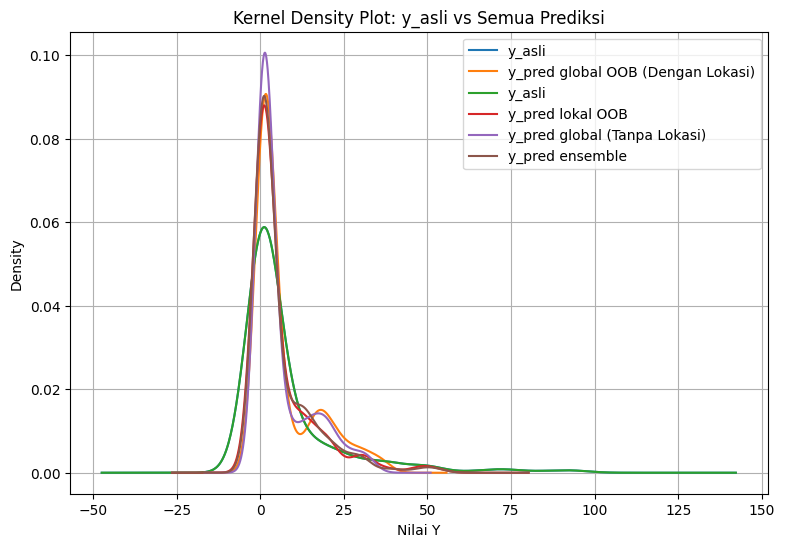

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Bisquare_Desember.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

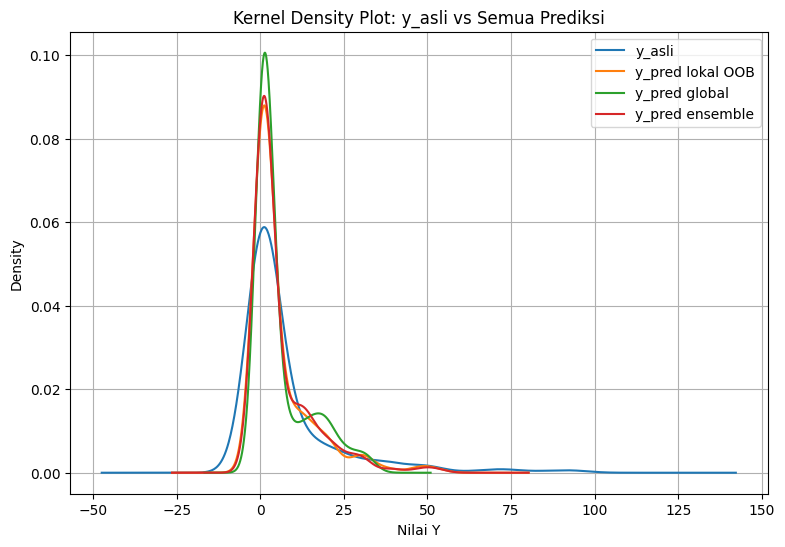

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults3['y_asli'].plot(kind='kde', label='y_asli')
LMResults3['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults3['yGhat'].plot(kind='kde', label='y_pred global')
LMResults3['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults3['Res_ensemble'] = (
    LMResults3['y_asli'] - LMResults3['y_ensemble']
)

##### Pengecekan Efek Spasial Autokorelasi Residual

In [ ]:
## XGBoost Global OOB
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.12995441368246963
p-value   : 0.001
z-score   : 3.9471240652959327


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual_tweedie_B = LMResults3['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : -0.020819517901472604
p-value   : 0.325
z-score   : -0.49917885865911693


In [ ]:
## XGBoost esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_B2 = LMResults3['y_asli'] - LMResults3['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_B2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.006837428947312308
p-value   : 0.338
z-score   : 0.3223413654487926


##### Prediksi Titik Baru

In [ ]:
def predict_new_gwxgboost_tweedie(
    X_train, y_train, Coords_train,
    X_new, Coords_new,
    BW_opt, params,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    feat_importance='gain',
    alpha_wt=0.5,
    alpha_wt_type='varying',
    random_state=42,
    path_save=False
):
    import os
    import numpy as np
    import pandas as pd
    from scipy.spatial import distance_matrix
    from xgboost import XGBRegressor

    # ======================================================
    # Validasi dan persiapan data
    # ======================================================
    X_train = pd.DataFrame(X_train).reset_index(drop=True).copy()
    y_train = pd.Series(np.ravel(y_train), name='y_asli').reset_index(drop=True)
    Coords_train = pd.DataFrame(Coords_train).reset_index(drop=True).copy()

    X_new = pd.DataFrame(X_new).reset_index(drop=True).copy()
    Coords_new = pd.DataFrame(Coords_new).reset_index(drop=True).copy()

    X_new.columns = X_train.columns

    if len(X_train) != len(y_train) or len(X_train) != len(Coords_train):
        raise ValueError("Panjang X_train, y_train, dan Coords_train harus sama.")

    if len(X_new) != len(Coords_new):
        raise ValueError("Panjang X_new dan Coords_new harus sama.")

    if (y_train < 0).any():
        raise ValueError("Semua nilai y_train harus >= 0 untuk objective Tweedie.")

    if Kernel not in ['Adaptive', 'Fixed']:
        raise ValueError("Kernel harus 'Adaptive' atau 'Fixed'.")

    if KernelFunction not in ['Bisquare', 'Gaussian']:
        raise ValueError("KernelFunction harus 'Bisquare' atau 'Gaussian'.")

    if alpha_wt_type not in ['fixed', 'varying']:
        raise ValueError("alpha_wt_type harus 'fixed' atau 'varying'.")

    # ======================================================
    # Persiapan alpha weight
    # ======================================================
    if alpha_wt_type == 'fixed':
        Alpha_Fixed = float(alpha_wt)

        if Alpha_Fixed < 0 or Alpha_Fixed > 1:
            raise ValueError("alpha_wt harus berada antara 0 dan 1.")

        Alpha_wtDF = None

    else:
        # Untuk varying, alpha_wt harus berisi alpha per titik training
        if isinstance(alpha_wt, dict) and 'alpha_wt' in alpha_wt:
            alpha_raw = alpha_wt['alpha_wt']

        elif isinstance(alpha_wt, pd.DataFrame):
            if 'alpha_wt' in alpha_wt.columns:
                alpha_raw = alpha_wt['alpha_wt']
            else:
                alpha_raw = alpha_wt.iloc[:, 0]

        else:
            alpha_raw = alpha_wt

        Alpha_wtDF = pd.Series(
            np.ravel(alpha_raw),
            name='alpha_wt'
        ).reset_index(drop=True)

        if len(Alpha_wtDF) != len(X_train):
            raise ValueError(
                "Untuk alpha_wt_type='varying', panjang alpha_wt harus sama "
                "dengan jumlah data training."
            )

        if ((Alpha_wtDF < 0) | (Alpha_wtDF > 1)).any():
            raise ValueError("Semua nilai alpha_wt varying harus berada antara 0 dan 1.")

        Alpha_Fixed = None

    # ======================================================
    # Parameter XGBoost Tweedie
    # ======================================================
    params = params.copy()
    params['objective'] = 'reg:tweedie'
    params['tweedie_variance_power'] = params.get(
        'tweedie_variance_power', 1.5
    )
    params['random_state'] = random_state

    # ======================================================
    # Fungsi bobot spasial
    # ======================================================
    def calc_spatial_weights(dist_series, h):
        dist_series = pd.Series(dist_series).astype(float)
        h = max(float(h), 1e-12)

        if KernelFunction == 'Bisquare':
            w = (1 - (dist_series.pow(2) / (h ** 2))).pow(2)
            w[dist_series >= h] = 0.0

        elif KernelFunction == 'Gaussian':
            w = np.exp(-0.5 * (dist_series / h) ** 2)

        return np.asarray(w, dtype=float)

    # ======================================================
    # Fungsi feature importance per lokasi
    # ======================================================
    def get_feature_importance_df(
        model,
        feature_names,
        ids_new,
        importance_type='gain'
    ):
        booster = model.get_booster()
        score = booster.get_score(importance_type=importance_type)

        importance_df = pd.DataFrame({
            'IDS_new': ids_new,
            'Feature': feature_names,
            'Importance': [
                score.get(feature, 0.0)
                for feature in feature_names
            ]
        })

        total_importance = importance_df['Importance'].sum()

        if total_importance > 0:
            importance_df['Importance_Relative'] = (
                importance_df['Importance'] / total_importance
            )
        else:
            importance_df['Importance_Relative'] = 0.0

        importance_df['Rank'] = importance_df['Importance'].rank(
            ascending=False,
            method='dense'
        ).astype(int)

        importance_df = importance_df.sort_values(
            by=['IDS_new', 'Rank', 'Importance'],
            ascending=[True, True, False]
        ).reset_index(drop=True)

        return importance_df

    # ======================================================
    # Model global Tweedie
    # ======================================================
    global_model = XGBRegressor(
        **params,
        importance_type=feat_importance
    )

    global_model.fit(X_train, y_train)

    # ======================================================
    # Distance matrix: titik baru ke titik training
    # ======================================================
    DistanceMatrix_NewTrain = pd.DataFrame(
        distance_matrix(Coords_new, Coords_train)
    )

    results = []
    local_models_new = []
    feature_importance_all = []

    print("================= Predict New Data GWXGBoost Tweedie =================")

    # ======================================================
    # Loop setiap titik baru
    # ======================================================
    for i in range(len(X_new)):

        print(f"Predicting new location {i + 1} of {len(X_new)}")

        dist_i = DistanceMatrix_NewTrain.iloc[i, :].reset_index(drop=True)

        nearest_train_id = int(dist_i.idxmin())

        DataLocal = pd.concat(
            [
                X_train,
                y_train.rename('y_asli'),
                pd.Series(dist_i, name='Distance')
            ],
            axis=1
        )

        DataLocalSorted = DataLocal.sort_values(
            by='Distance'
        ).reset_index(drop=True)

        # ==================================================
        # Ambil data lokal berdasarkan bandwidth
        # ==================================================
        if Kernel == 'Adaptive':
            knn = int(BW_opt)

            if knn < 2:
                raise ValueError("BW_opt Adaptive minimal harus 2.")

            LocalData = DataLocalSorted.iloc[:knn, :].copy()
            h = float(LocalData['Distance'].max())

        else:
            bw = float(BW_opt)

            LocalData = DataLocalSorted[
                DataLocalSorted['Distance'] < bw
            ].copy()

            h = bw

        if LocalData.shape[0] < 2:
            raise ValueError(
                f"Jumlah data lokal untuk titik baru ke-{i} terlalu sedikit."
            )

        h = max(h, 1e-12)

        LocalX = LocalData.iloc[:, :-2]
        LocalY = LocalData['y_asli']

        LocalX.columns = X_train.columns

        # ==================================================
        # Bobot spasial
        # ==================================================
        if spatial_weights:
            SpatialWeights = calc_spatial_weights(
                LocalData['Distance'], h
            )
        else:
            SpatialWeights = None

        # ==================================================
        # Model lokal Tweedie untuk titik baru
        # ==================================================
        local_model = XGBRegressor(
            **params,
            importance_type=feat_importance
        )

        if spatial_weights:
            local_model.fit(
                LocalX,
                LocalY,
                sample_weight=SpatialWeights
            )
        else:
            local_model.fit(LocalX, LocalY)

        local_models_new.append(local_model)

        # ==================================================
        # Feature importance lokal per lokasi baru
        # ==================================================
        imp_i = get_feature_importance_df(
            model=local_model,
            feature_names=list(X_train.columns),
            ids_new=i,
            importance_type=feat_importance
        )

        feature_importance_all.append(imp_i)

        top_features = (
            imp_i
            .sort_values('Importance_Relative', ascending=False)
            .head(5)['Feature']
            .tolist()
        )

        # ==================================================
        # Prediksi lokal langsung skala asli Tweedie
        # ==================================================
        y_local = float(local_model.predict(X_new.iloc[[i]])[0])
        y_local = max(y_local, 0.0)

        # ==================================================
        # Prediksi global langsung skala asli Tweedie
        # ==================================================
        y_global = float(global_model.predict(X_new.iloc[[i]])[0])
        y_global = max(y_global, 0.0)

        # ==================================================
        # Alpha weight fixed atau varying
        # ==================================================
        if alpha_wt_type == 'fixed':
            Alpha_wt = Alpha_Fixed
            Alpha_Source = 'fixed'

        else:
            Alpha_wt = float(Alpha_wtDF.iloc[nearest_train_id])
            Alpha_Source = f'nearest_train_id_{nearest_train_id}'

        Beta_wt = 1 - Alpha_wt

        # ==================================================
        # Ensemble local + global
        # ==================================================
        y_ensemble = Alpha_wt * y_local + Beta_wt * y_global
        y_ensemble = max(float(y_ensemble), 0.0)

        results.append({
            'IDS_new': i,
            'Nearest_Train_ID': nearest_train_id,
            'Distance_to_Nearest': float(dist_i.min()),
            'Local_Pred': y_local,
            'Global_Pred': y_global,
            'alpha_wt_type': alpha_wt_type,
            'alpha_source': Alpha_Source,
            'alpha_wt': Alpha_wt,
            'beta_wt': Beta_wt,
            'Ensemble_Pred': y_ensemble,
            'Top_Features': ', '.join(top_features)
        })

    Prediction_New = pd.DataFrame(results)

    Feature_Importance_New = pd.concat(
        feature_importance_all,
        ignore_index=True
    )

    # ======================================================
    # Simpan hasil
    # ======================================================
    if path_save:
        os.makedirs(path_save, exist_ok=True)

        Prediction_New.to_csv(
            os.path.join(path_save, 'Prediction_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

        Feature_Importance_New.to_csv(
            os.path.join(path_save, 'Feature_Importance_New_GWXGBoost_Tweedie.csv'),
            index=False
        )

    output = {
        'Prediction_New': Prediction_New,
        'Feature_Importance_New': Feature_Importance_New,
        'local_models_new': local_models_new,
        'global_model': global_model
    }

    return output

In [ ]:
# 1) Baca Excel (sheet pertama)
prediksi = pd.read_excel("/content/data_prediksi_des-feb.xlsx")
prediksi.info()
Coords_baru = prediksi[['Longitude', 'Latitude']]
X_baru = prediksi[['so', 'thetao', 'zos','uo', 'vo', 'chl', 'o2', 'mlotst', 'nppv']]
VarNames = X.columns[:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 310 entries, 0 to 309
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Longitude  310 non-null    float64
 1   Latitude   310 non-null    float64
 2   periode    310 non-null    object 
 3   so         310 non-null    float64
 4   thetao     310 non-null    float64
 5   zos        310 non-null    float64
 6   uo         310 non-null    float64
 7   vo         310 non-null    float64
 8   chl        310 non-null    float64
 9   o2         310 non-null    float64
 10  mlotst     310 non-null    float64
 11  nppv       310 non-null    float64
dtypes: float64(11), object(1)
memory usage: 29.2+ KB


In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_B = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=66,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Bisquare',
    spatial_weights=True,
    alpha_wt=output_model3['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 310
Predicting new location 2 of 310
Predicting new location 3 of 310
Predicting new location 4 of 310
Predicting new location 5 of 310
Predicting new location 6 of 310
Predicting new location 7 of 310
Predicting new location 8 of 310
Predicting new location 9 of 310
Predicting new location 10 of 310
Predicting new location 11 of 310
Predicting new location 12 of 310
Predicting new location 13 of 310
Predicting new location 14 of 310
Predicting new location 15 of 310
Predicting new location 16 of 310
Predicting new location 17 of 310
Predicting new location 18 of 310
Predicting new location 19 of 310
Predicting new location 20 of 310
Predicting new location 21 of 310
Predicting new location 22 of 310
Predicting new location 23 of 310
Predicting new location 24 of 310
Predicting new location 25 of 310
Predicting new location 26 of 310
Predicting new location 27 of 310
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_B['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,135,0.500000,0.688760,0.865585,varying,nearest_train_id_135,1.0,0.0,0.688760,"so, thetao, zos, uo, vo"
1,1,135,0.500000,0.681266,0.647739,varying,nearest_train_id_135,1.0,0.0,0.681266,"so, thetao, zos, uo, vo"
2,2,135,0.707107,0.640965,0.832254,varying,nearest_train_id_135,1.0,0.0,0.640965,"so, thetao, zos, uo, vo"
3,3,142,0.500000,0.628298,0.777817,varying,nearest_train_id_142,1.0,0.0,0.628298,"so, thetao, zos, uo, vo"
4,4,142,0.707107,0.632089,1.113778,varying,nearest_train_id_142,1.0,0.0,0.632089,"so, thetao, zos, uo, vo"
...,...,...,...,...,...,...,...,...,...,...,...
305,305,145,0.500000,0.830591,1.602441,varying,nearest_train_id_145,1.0,0.0,0.830591,"so, thetao, zos, uo, vo"
306,306,147,0.500000,0.739279,0.801031,varying,nearest_train_id_147,1.0,0.0,0.739279,"vo, so, thetao, zos, uo"
307,307,148,0.500000,0.711334,2.208649,varying,nearest_train_id_148,1.0,0.0,0.711334,"so, thetao, zos, uo, vo"
308,308,147,0.500000,0.620017,0.664972,varying,nearest_train_id_147,1.0,0.0,0.620017,"so, thetao, zos, uo, vo"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_B['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Desember_Bisquare.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local'] = hasil_prediksi_Tweedie_B['Prediction_New']['Local_Pred']
prediksi['Pred_Global'] = hasil_prediksi_Tweedie_B['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble'] = hasil_prediksi_Tweedie_B['Prediction_New']['Ensemble_Pred']
prediksi['alpha_wt'] = hasil_prediksi_Tweedie_B['Prediction_New']['alpha_wt']
prediksi['beta_wt'] = hasil_prediksi_Tweedie_B['Prediction_New']['beta_wt']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Bisquare_Desember.xlsx',
    index=False
)

#### Adaptive Gaussian

In [ ]:
output_model4 = build_local_gwxgboost_tweedie(
    X=X,
    y=y,
    Coords=Coords,
    BW_opt=52,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    n_splits=3,
    feat_importance='gain',
    alpha_wt_type='varying',
    alpha_wt=0.5,
    random_state=42,
    path_save='hasil_model_lokal'
)

================= Building Local GWXGBoost Tweedie =================
================= Global importance by gain has been calculated =================
Calculating local model 1 of 300
Calculating local model 2 of 300
Calculating local model 3 of 300
Calculating local model 4 of 300
Calculating local model 5 of 300
Calculating local model 6 of 300
Calculating local model 7 of 300
Calculating local model 8 of 300
Calculating local model 9 of 300
Calculating local model 10 of 300
Calculating local model 11 of 300
Calculating local model 12 of 300
Calculating local model 13 of 300
Calculating local model 14 of 300
Calculating local model 15 of 300
Calculating local model 16 of 300
Calculating local model 17 of 300
Calculating local model 18 of 300
Calculating local model 19 of 300
Calculating local model 20 of 300
Calculating local model 21 of 300
Calculating local model 22 of 300
Calculating local model 23 of 300
Calculating local model 24 of 300
Calculating local model 25 of 300
Calculat

In [ ]:
LMResults4 = output_model4['Prediction']
Evaluation_Results4 = output_model4['Evaluation']

LMResults4.head(300)

,IDS,y_asli,LM_yPred,LM_yOOB,LM_ResOOB,LMRsqr,LM_Best_score_MAE,LM_Best_score_RMSE,alpha_wt,yGhat,...,MaxFeatureID,Imp_so,Imp_thetao,Imp_zos,Imp_uo,Imp_vo,Imp_chl,Imp_o2,Imp_mlotst,Imp_nppv
0,0,18.318995,16.810591,11.036044,7.282951,-0.206856,16.418672,23.251208,0.5,21.342607,...,mlotst,0.071016,0.124323,0.109729,0.084162,0.125115,0.143426,0.080769,0.173466,0.087994
1,1,15.934011,13.572657,11.042100,4.891911,0.100973,14.485605,20.441257,0.5,13.482290,...,thetao,0.103745,0.158777,0.105624,0.130986,0.101459,0.092535,0.066948,0.102421,0.137504
2,2,9.870458,12.475152,16.220480,-6.350022,-0.122640,15.336167,22.995797,0.5,6.634219,...,nppv,0.077542,0.120327,0.123886,0.108547,0.098421,0.120096,0.089538,0.116645,0.144997
3,3,30.287245,25.726765,22.584133,7.703112,-1.094502,17.594949,24.984414,1.0,8.711604,...,uo,0.093508,0.136267,0.061266,0.178783,0.098933,0.117505,0.090330,0.091163,0.132245
4,4,18.029441,18.582769,18.804695,-0.775254,-0.225818,15.564563,22.910289,1.0,9.165597,...,chl,0.092137,0.091060,0.113153,0.117640,0.099243,0.142031,0.088936,0.124747,0.131053
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,295,4.129491,3.258757,3.224047,0.905444,-0.067540,3.361802,7.442955,0.5,4.142704,...,chl,0.084140,0.114468,0.114057,0.071417,0.100644,0.187100,0.131537,0.132378,0.064260
296,296,5.518971,3.246525,0.636909,4.882061,-0.020604,3.319094,7.587081,0.5,1.150057,...,mlotst,0.150200,0.068830,0.079323,0.132851,0.069994,0.153850,0.120220,0.169697,0.055036
297,297,0.036587,1.354225,2.294814,-2.258227,-0.272598,3.342476,7.023494,0.5,0.932936,...,nppv,0.136838,0.097353,0.126943,0.071475,0.072693,0.134098,0.099883,0.107368,0.153348
298,298,48.590695,28.401833,1.666033,46.924662,-0.113073,2.446068,5.022597,1.0,1.088990,...,mlotst,0.066391,0.111050,0.089541,0.102410,0.101469,0.135680,0.147824,0.156897,0.088737


In [ ]:
LMResults4.to_excel(
    'LMResults_GWXGB_Tweedie_Gaussian_Desember.xlsx',
    index=False
)

In [ ]:
Evaluation_Results4

,Model,Kolom_Prediksi,R2,MAE,RMSE
0,Local XGBoost Tweedie - Pred,LM_yPred,0.952205,1.679964,3.399714
1,Local XGBoost Tweedie - OOB,LM_yOOB,0.370186,5.386902,12.341172
2,Global XGBoost Tweedie - OOB,yGhat,0.335079,5.834868,12.680469
3,Ensemble Local + Global,y_ensemble,0.443852,4.817029,11.596995


<Figure size 900x600 with 0 Axes>

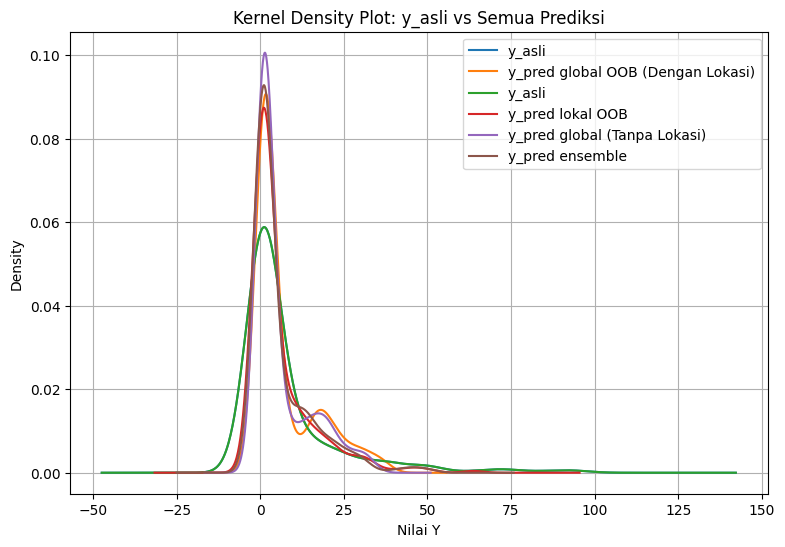

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Gaussian_Desember.xlsx")
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# ambil tabel prediksi
GlobalResults = global_oob_tweedie['Prediction']

plt.figure(figsize=(9, 6))

GlobalResults['y_asli'].plot(
    kind='kde',
    label='y_asli'
)

GlobalResults['yGhat'].plot(
    kind='kde',
    label='y_pred global OOB (Dengan Lokasi)'
)

LMResults['y_asli'].plot(kind='kde', label='y_asli')
LMResults['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults['yGhat'].plot(kind='kde', label='y_pred global (Tanpa Lokasi)')
LMResults['y_ensemble'].plot(kind='kde', label='y_pred ensemble')


plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

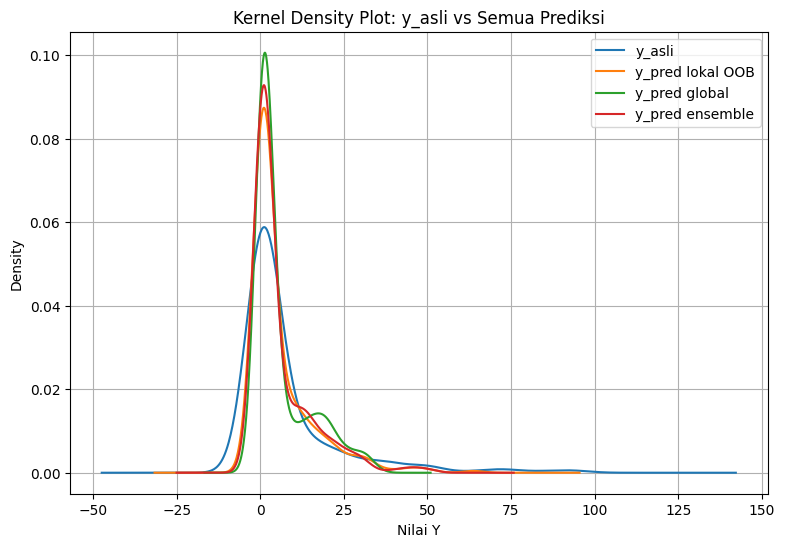

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

LMResults4['y_asli'].plot(kind='kde', label='y_asli')
LMResults4['LM_yOOB'].plot(kind='kde', label='y_pred lokal OOB')
LMResults4['yGhat'].plot(kind='kde', label='y_pred global')
LMResults4['y_ensemble'].plot(kind='kde', label='y_pred ensemble')

plt.xlabel('Nilai Y')
plt.ylabel('Density')
plt.title('Kernel Density Plot: y_asli vs Semua Prediksi')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
LMResults = pd.read_excel("/content/LMResults_GWXGB_Tweedie_Gaussian_Desember.xlsx")
LMResults.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 22 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   IDS                 300 non-null    int64  
 1   y_asli              300 non-null    float64
 2   LM_yPred            300 non-null    float64
 3   LM_yOOB             300 non-null    float64
 4   LM_ResOOB           300 non-null    float64
 5   LMRsqr              300 non-null    float64
 6   LM_Best_score_MAE   300 non-null    float64
 7   LM_Best_score_RMSE  300 non-null    float64
 8   alpha_wt            300 non-null    float64
 9   yGhat               300 non-null    float64
 10  y_ensemble          300 non-null    float64
 11  MaxImportance       300 non-null    float64
 12  MaxFeatureID        300 non-null    object 
 13  Imp_so              300 non-null    float64
 14  Imp_thetao          300 non-null    float64
 15  Imp_zos             300 non-null    float64
 16  Imp_uo  

In [ ]:
# Korelasi antara y_asli dan y_ensemble
korelasi = LMResults['y_asli'].corr(LMResults['y_ensemble'])

print(f"Nilai korelasi Pearson: {korelasi:.4f}")

Nilai korelasi Pearson: 0.6836


##### Pengecekan Autokorelasi Spasial

In [ ]:
LMResults4['Res_ensemble'] = (
    LMResults4['y_asli'] - LMResults4['y_ensemble']
)

In [ ]:
## XGBoost Global
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['yGhat']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.12995441368246963
p-value   : 0.001
z-score   : 3.9471240652959327


In [ ]:
## XGBoost Lokal
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual lokal OOB
residual_tweedie_G = LMResults4['LM_ResOOB']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : -0.0243244637606457
p-value   : 0.291
z-score   : -0.6051237646219638


In [ ]:
## XGBoost Esemble
from libpysal.weights import KNN
from esda.moran import Moran
np.random.seed(42)

# residual ensemble
residual_tweedie_G2 = LMResults4['y_asli'] - LMResults4['y_ensemble']

# koordinat
coords = list(zip(Coords.iloc[:, 0], Coords.iloc[:, 1]))

# bobot spasial K-nearest neighbors
w = KNN.from_array(coords, k=5)

# standardisasi row
w.transform = 'R'

# Moran's I
mi = Moran(residual_tweedie_G2, w)

print("Moran's I :", mi.I)
print("p-value   :", mi.p_sim)
print("z-score   :", mi.z_sim)

Moran's I : 0.018562117308237345
p-value   : 0.215
z-score   : 0.66774007133711


##### Prediksi Titik Baru

In [ ]:
# ======================================================
# 5. Prediksi titik baru
# ======================================================
hasil_prediksi_Tweedie_G = predict_new_gwxgboost_tweedie(
    X_train=X,
    y_train=y,
    Coords_train=Coords,
    X_new=X_baru,
    Coords_new=Coords_baru,
    BW_opt=52,
    params=xgb_params2,
    Kernel='Adaptive',
    KernelFunction='Gaussian',
    spatial_weights=True,
    alpha_wt=output_model4['alpha_wt'],
    alpha_wt_type='varying',
    random_state=42,
    path_save='hasil_prediksi_baru'
)

================= Predict New Data GWXGBoost Tweedie =================
Predicting new location 1 of 310
Predicting new location 2 of 310
Predicting new location 3 of 310
Predicting new location 4 of 310
Predicting new location 5 of 310
Predicting new location 6 of 310
Predicting new location 7 of 310
Predicting new location 8 of 310
Predicting new location 9 of 310
Predicting new location 10 of 310
Predicting new location 11 of 310
Predicting new location 12 of 310
Predicting new location 13 of 310
Predicting new location 14 of 310
Predicting new location 15 of 310
Predicting new location 16 of 310
Predicting new location 17 of 310
Predicting new location 18 of 310
Predicting new location 19 of 310
Predicting new location 20 of 310
Predicting new location 21 of 310
Predicting new location 22 of 310
Predicting new location 23 of 310
Predicting new location 24 of 310
Predicting new location 25 of 310
Predicting new location 26 of 310
Predicting new location 27 of 310
Predicting new locat

In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
hasil_prediksi_Tweedie_G['Prediction_New']

,IDS_new,Nearest_Train_ID,Distance_to_Nearest,Local_Pred,Global_Pred,alpha_wt_type,alpha_source,alpha_wt,beta_wt,Ensemble_Pred,Top_Features
0,0,135,0.500000,0.616912,0.865585,varying,nearest_train_id_135,1.0,0.0,0.616912,"zos, uo, so, vo, mlotst"
1,1,135,0.500000,0.375879,0.647739,varying,nearest_train_id_135,1.0,0.0,0.375879,"uo, so, vo, o2, thetao"
2,2,135,0.707107,0.417473,0.832254,varying,nearest_train_id_135,1.0,0.0,0.417473,"o2, vo, so, chl, nppv"
3,3,142,0.500000,0.440886,0.777817,varying,nearest_train_id_142,0.5,0.5,0.609351,"so, chl, thetao, o2, vo"
4,4,142,0.707107,0.372878,1.113778,varying,nearest_train_id_142,0.5,0.5,0.743328,"uo, vo, chl, so, thetao"
...,...,...,...,...,...,...,...,...,...,...,...
305,305,145,0.500000,1.524295,1.602441,varying,nearest_train_id_145,0.5,0.5,1.563368,"vo, uo, thetao, so, chl"
306,306,147,0.500000,1.031137,0.801031,varying,nearest_train_id_147,1.0,0.0,1.031137,"thetao, uo, o2, mlotst, zos"
307,307,148,0.500000,0.430218,2.208649,varying,nearest_train_id_148,1.0,0.0,0.430218,"zos, chl, uo, so, nppv"
308,308,147,0.500000,0.851685,0.664972,varying,nearest_train_id_147,1.0,0.0,0.851685,"vo, chl, so, nppv, thetao"


In [ ]:
# ======================================================
# 6. Lihat hasil prediksi
# ======================================================
Feature_Importance_New = hasil_prediksi_Tweedie_G['Feature_Importance_New']
# Simpan ke Excel
Feature_Importance_New.to_excel(
    'Feature_Importance_New_Tweedie_Desember_Gaussian.xlsx',
    index=False
)

In [ ]:
# Gabungkan hasil prediksi ke data_baru
prediksi['Pred_Local_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Local_Pred']
prediksi['Pred_Global_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Global_Pred']
prediksi['Pred_Ensemble_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['Ensemble_Pred']
prediksi['alpha_wt_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['alpha_wt']
prediksi['beta_wt_Gaussian'] = hasil_prediksi_Tweedie_G['Prediction_New']['beta_wt']

# Simpan ke Excel
prediksi.to_excel(
    'hasil_prediksi_data_Tweedie_Gaussian_Desember.xlsx',
    index=False
)

## Visualisasi Akhir Analisis


### Hasil Prediksi

In [ ]:
# 1) Baca Excel (sheet pertama)
visual2 = pd.read_excel("/content/Data Visualisasi Prediksi Akhir_Tweedie.xlsx")
visual2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610 entries, 0 to 609
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Longitude                  610 non-null    float64
 1   Latitude                   610 non-null    float64
 2   Prediksi_Lokal_Gaussian    610 non-null    float64
 3   Prediksi_Global_Gaussian   610 non-null    float64
 4   Prediksi_Esemble_Gaussian  610 non-null    float64
 5   Max_Fitur_Gaussian         610 non-null    object 
dtypes: float64(5), object(1)
memory usage: 28.7+ KB


In [ ]:
visual_des = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Prediksi_Lokal_Gaussian']],
    on=['Longitude', 'Latitude'],
    how='left'
)

/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_cultural/ne_10m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


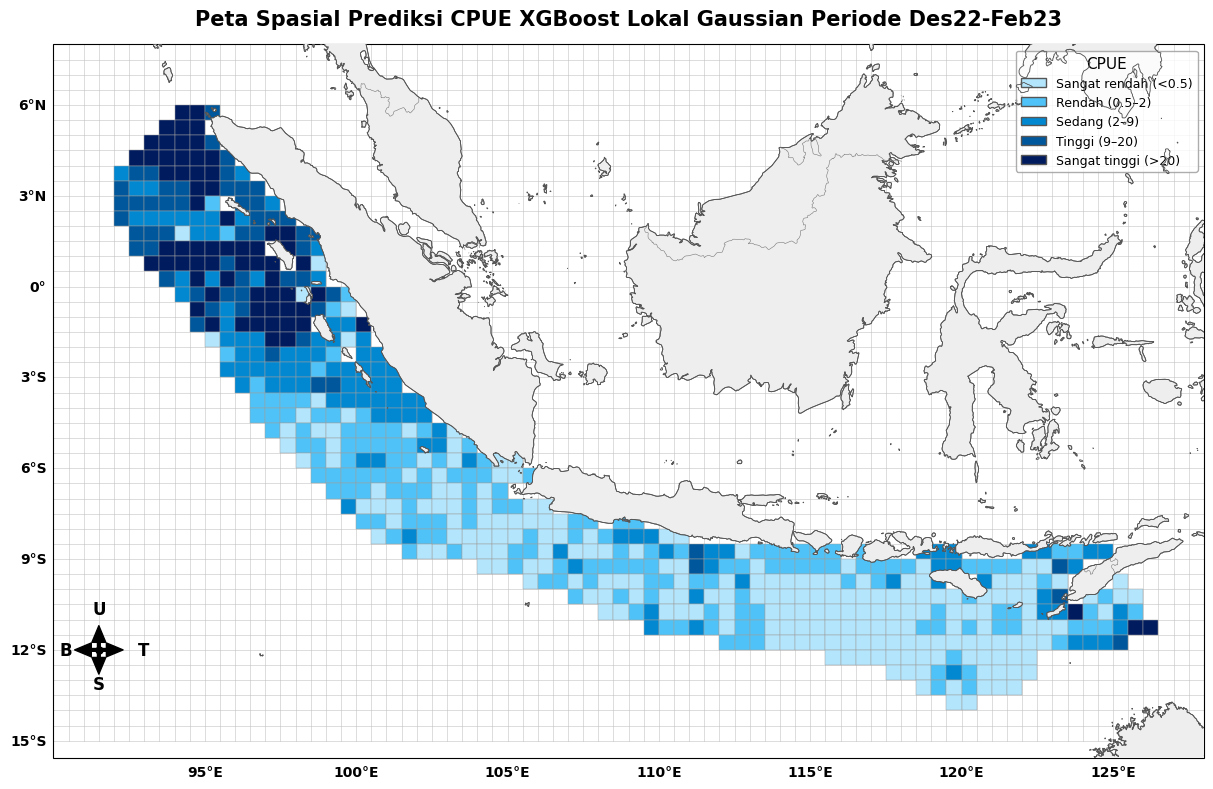

In [ ]:
value_col = 'Prediksi_Lokal_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_des.copy()
plot_data[value_col] = pd.to_numeric(plot_data[value_col], errors='coerce')
plot_data['cpue_plot'] = plot_data[value_col].where(plot_data[value_col] > 0)

# Kategori CPUE
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

fig = plt.figure(figsize=(13, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([lon_min, lon_max, lat_min, lat_max])
ax.set_facecolor('#ffffff')

# Grid diperjelas
for lon in np.arange(lon_min, lon_max + grid_size, grid_size):
    ax.plot([lon, lon], [lat_min, lat_max],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

for lat in np.arange(lat_min, lat_max + grid_size, grid_size):
    ax.plot([lon_min, lon_max], [lat, lat],
            color='#bdbdbd', linewidth=0.45, alpha=0.8,
            transform=ccrs.PlateCarree(), zorder=1)

# Plot grid CPUE
for _, row in plot_data.iterrows():
    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (lon_min <= lon <= lon_max and lat_min <= lat <= lat_max):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (lon - grid_size/2, lat - grid_size/2),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )
    ax.add_patch(rect)

# Daratan abu-abu samar
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(land, linewidth=0.6, zorder=5)
ax.add_feature(cfeature.COASTLINE.with_scale('10m'),
               linewidth=0.6, edgecolor='#555555', zorder=6)
ax.add_feature(cfeature.BORDERS.with_scale('10m'),
               linewidth=0.4, edgecolor='#777777', zorder=6)

# Label koordinat
gl = ax.gridlines(draw_labels=True, linewidth=0, color='none')
gl.top_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 10, 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'weight': 'bold'}

# Legend
legend_patches = [
    patches.Patch(facecolor=colors_cpue[i],
                  edgecolor='#555555',
                  label=labels[i])
    for i in range(len(labels))
]

ax.legend(handles=legend_patches,
          title='CPUE',
          loc='upper right',
          frameon=True,
          edgecolor='#999999',
          fontsize=9,
          title_fontsize=11)

# Mata angin lengkap
x_c, y_c = 91.5, -12
panjang = 0.8

# titik pusat
ax.scatter(x_c, y_c, color='black', s=25, transform=ccrs.PlateCarree(), zorder=10)

# U
ax.annotate('', xy=(x_c, y_c+panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c+panjang+0.4, 'U', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# S
ax.annotate('', xy=(x_c, y_c-panjang), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c, y_c-panjang-0.5, 'S', ha='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# T
ax.annotate('', xy=(x_c+panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c+panjang+0.5, y_c, 'T', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

# B
ax.annotate('', xy=(x_c-panjang, y_c), xytext=(x_c, y_c),
            arrowprops=dict(facecolor='black', width=2, headwidth=10),
            xycoords=ccrs.PlateCarree()._as_mpl_transform(ax))
ax.text(x_c-panjang-0.5, y_c, 'B', va='center', fontsize=12, fontweight='bold',
        transform=ccrs.PlateCarree())

ax.set_title('Peta Spasial Prediksi CPUE XGBoost Lokal Gaussian Periode Des22-Feb23',
             fontsize=15, fontweight='bold', pad=14)

plt.tight_layout()
plt.show()

In [ ]:
visual_des2 = pd.merge(
    WPP,
    visual2[['Longitude', 'Latitude', 'Prediksi_Esemble_Gaussian']],
    on=['Longitude', 'Latitude'],
    how='left'
)

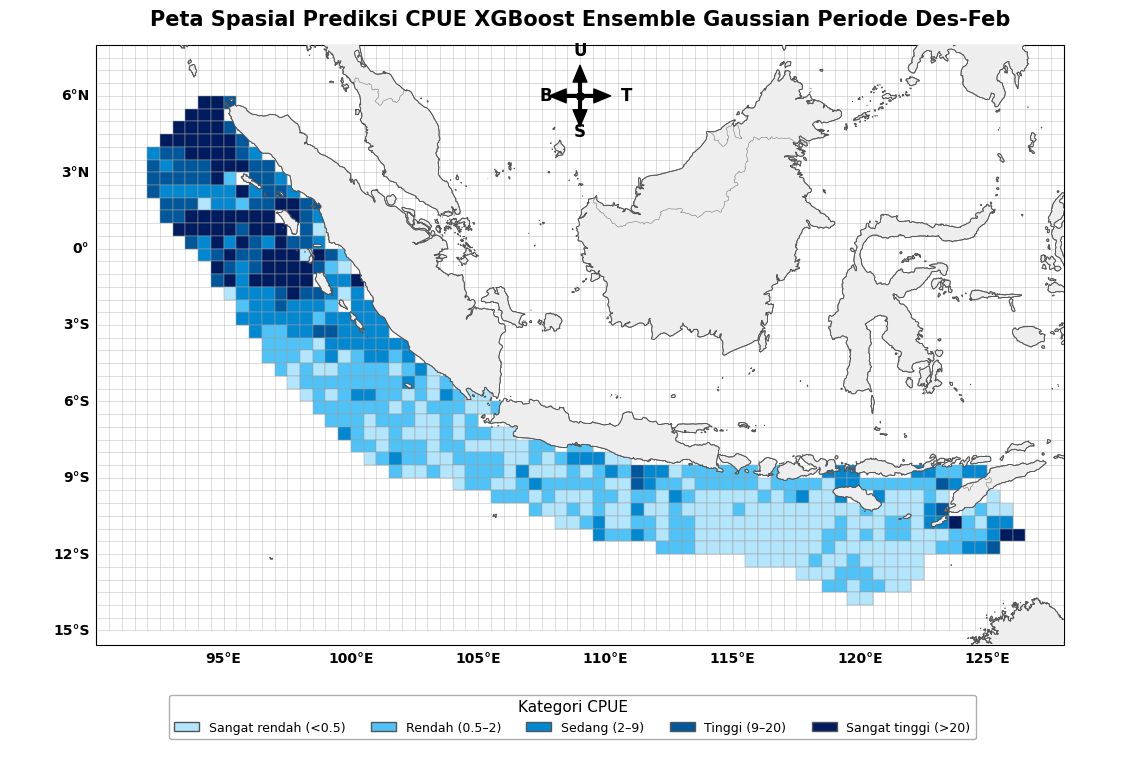

In [ ]:
import matplotlib.colors as mcolors

# =========================
# 1. PARAMETER
# =========================
value_col = 'Prediksi_Esemble_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual_des2.copy()

plot_data[value_col] = pd.to_numeric(
    plot_data[value_col],
    errors='coerce'
)

plot_data['cpue_plot'] = (
    plot_data[value_col]
    .where(plot_data[value_col] > 0)
)

# =========================
# 2. KATEGORI CPUE
# =========================
bins = [0, 0.5, 2, 9, 20, 100]

labels = [
    'Sangat rendah (<0.5)',
    'Rendah (0.5–2)',
    'Sedang (2–9)',
    'Tinggi (9–20)',
    'Sangat tinggi (>20)'
]

# Warna biru kontras
colors_cpue = [
    '#B3E5FC',
    '#4FC3F7',
    '#0288D1',
    '#01579B',
    '#001B5E'
]

cmap = mcolors.ListedColormap(colors_cpue)
norm = mcolors.BoundaryNorm(bins, cmap.N)

# =========================
# 3. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.12, 0.02, 0.75, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 4. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#bdbdbd',
        linewidth=0.45,
        alpha=0.8,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 5. PLOT GRID CPUE
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    val = row['cpue_plot']

    if pd.isna(val):
        continue

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    val = min(val, 100)

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=cmap(norm(val)),
        edgecolor='#9e9e9e',
        linewidth=0.35,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 6. DARATAN
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 7. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 10,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 10,
    'weight': 'bold'
}

# =========================
# 8. LEGENDE HORIZONTAL
# =========================
legend_patches = [
    patches.Patch(
        facecolor=colors_cpue[i],
        edgecolor='#555555',
        label=labels[i]
    )
    for i in range(len(labels))
]

legend_ax.legend(
    handles=legend_patches,
    title='Kategori CPUE',
    loc='center',
    ncol=5,
    frameon=True,
    edgecolor='#999999',
    fontsize=9,
    title_fontsize=11
)

# =========================
# 9. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 10. JUDUL
# =========================
ax.set_title(
    'Peta Spasial Prediksi CPUE XGBoost Ensemble Gaussian Periode Des-Feb',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

### Fitur Penting

#### Fitur Penting global

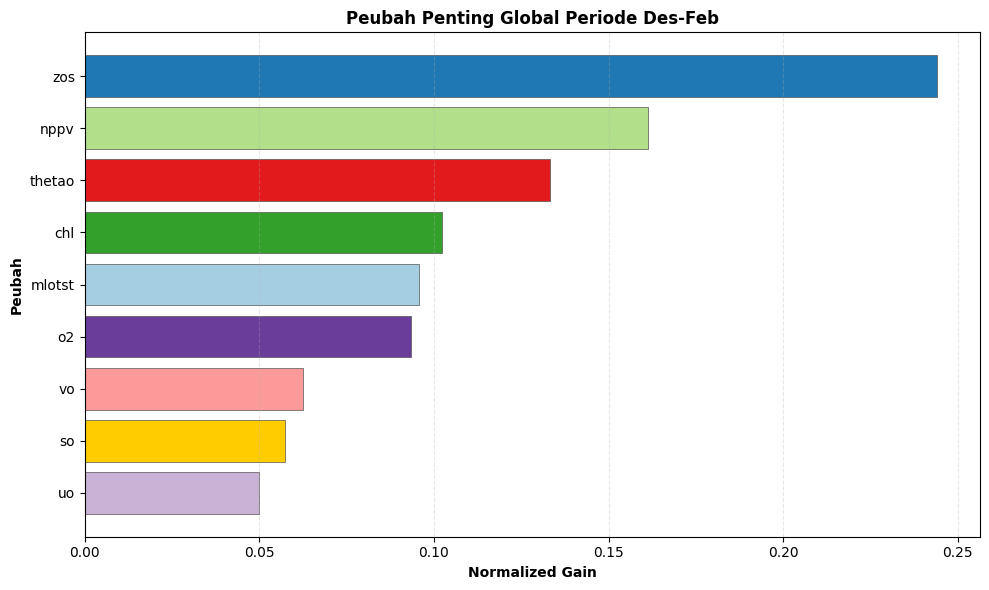

In [ ]:
import matplotlib.pyplot as plt

global_imp = output_model4['GlobalImportance'].copy()

global_imp = global_imp.sort_values(
    by='Gain_Normalized',
    ascending=False
).reset_index(drop=True)

# Mapping warna fitur
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Warna bar sesuai nama Feature
bar_colors = [
    colors_feature.get(feature, '#bdbdbd')
    for feature in global_imp['Feature']
]

plt.figure(figsize=(10, 6))

plt.barh(
    global_imp['Feature'],
    global_imp['Gain_Normalized'],
    color=bar_colors,
    edgecolor='#555555',
    linewidth=0.5
)

plt.gca().invert_yaxis()

plt.xlabel('Normalized Gain', fontweight='bold')
plt.ylabel('Peubah', fontweight='bold')
plt.title('Peubah Penting Global Periode Des-Feb', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

#### Fitur Penting Lokal

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# daftar unik fitur
fitur_unik = visual2['Max_Fitur_Gaussian'].unique()

# colormap
cmap = plt.cm.get_cmap('tab10', len(fitur_unik))

# mapping warna
color_map = {fitur: cmap(i) for i, fitur in enumerate(fitur_unik)}

# buat kolom warna
visual2['color'] = visual2['Max_Fitur_Gaussian'].map(color_map)

/tmp/ipykernel_9831/1240998469.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(fitur_unik))


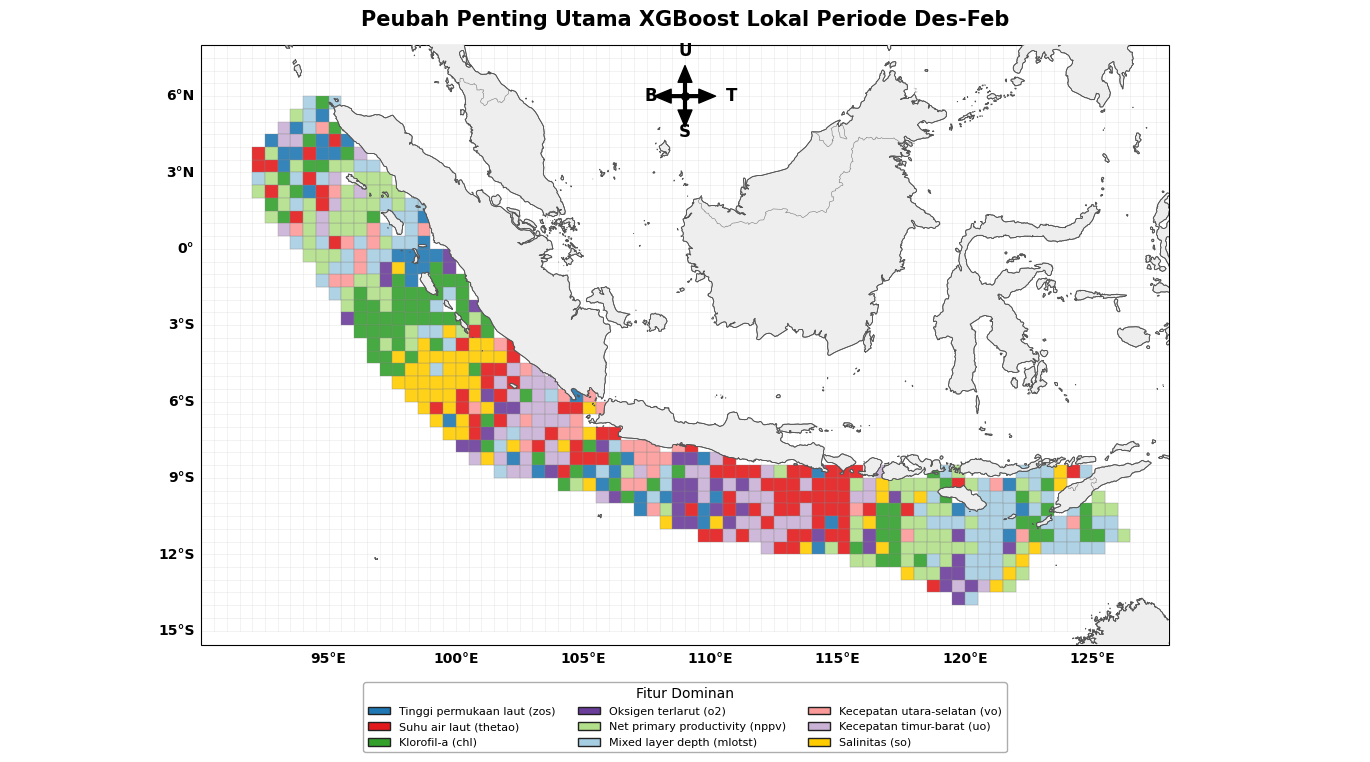

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# =========================
# 1. PARAMETER PETA
# =========================
feature_col = 'Max_Fitur_Gaussian'
grid_size = 0.5

lon_min, lon_max = 90, 128
lat_min, lat_max = -15, 8

plot_data = visual2.copy()

plot_data['Longitude'] = pd.to_numeric(
    plot_data['Longitude'],
    errors='coerce'
)

plot_data['Latitude'] = pd.to_numeric(
    plot_data['Latitude'],
    errors='coerce'
)

plot_data = plot_data.dropna(
    subset=['Longitude', 'Latitude', feature_col]
)

# =========================
# 2. WARNA FITUR DOMINAN
# =========================
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# =========================
# 3. LABEL FITUR
# =========================
feature_labels = {
    'zos': 'Tinggi permukaan laut (zos)',
    'thetao': 'Suhu air laut (thetao)',
    'chl': 'Klorofil-a (chl)',
    'o2': 'Oksigen terlarut (o2)',
    'nppv': 'Net primary productivity (nppv)',
    'mlotst': 'Mixed layer depth (mlotst)',
    'vo': 'Kecepatan utara-selatan (vo)',
    'uo': 'Kecepatan timur-barat (uo)',
    'so': 'Salinitas (so)'
}

feature_order = [
    'zos',
    'thetao',
    'chl',
    'o2',
    'nppv',
    'mlotst',
    'vo',
    'uo',
    'so'
]

plot_data['color'] = (
    plot_data[feature_col]
    .map(colors_feature)
    .fillna('#bdbdbd')
)

# =========================
# 4. FIGURE
# =========================
fig = plt.figure(figsize=(15, 8))

# Peta utama
ax = fig.add_axes(
    [0.05, 0.15, 0.90, 0.75],
    projection=ccrs.PlateCarree()
)

# Legend horizontal bawah
legend_ax = fig.add_axes([0.05, 0.02, 0.90, 0.08])
legend_ax.axis('off')

ax.set_extent([
    lon_min,
    lon_max,
    lat_min,
    lat_max
])

ax.set_facecolor('#ffffff')

# =========================
# 5. GRID 0.5 DERAJAT
# =========================
for lon in np.arange(
    lon_min,
    lon_max + grid_size,
    grid_size
):
    ax.plot(
        [lon, lon],
        [lat_min, lat_max],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

for lat in np.arange(
    lat_min,
    lat_max + grid_size,
    grid_size
):
    ax.plot(
        [lon_min, lon_max],
        [lat, lat],
        color='#d6d6d6',
        linewidth=0.45,
        alpha=0.5,
        transform=ccrs.PlateCarree(),
        zorder=1
    )

# =========================
# 6. PLOT GRID FITUR DOMINAN
# =========================
for _, row in plot_data.iterrows():

    lon = row['Longitude']
    lat = row['Latitude']
    warna = row['color']

    if not (
        lon_min <= lon <= lon_max
        and
        lat_min <= lat <= lat_max
    ):
        continue

    rect = patches.Rectangle(
        (
            lon - grid_size / 2,
            lat - grid_size / 2
        ),
        grid_size,
        grid_size,
        facecolor=warna,
        edgecolor='#8a8a8a',
        linewidth=0.25,
        alpha=0.9,
        transform=ccrs.PlateCarree(),
        zorder=2
    )

    ax.add_patch(rect)

# =========================
# 7. DARATAN DAN BATAS
# =========================
land = cfeature.NaturalEarthFeature(
    category='physical',
    name='land',
    scale='10m',
    facecolor='#eeeeee',
    edgecolor='#555555'
)

ax.add_feature(
    land,
    linewidth=0.6,
    zorder=5
)

ax.add_feature(
    cfeature.COASTLINE.with_scale('10m'),
    linewidth=0.6,
    edgecolor='#555555',
    zorder=6
)

ax.add_feature(
    cfeature.BORDERS.with_scale('10m'),
    linewidth=0.4,
    edgecolor='#777777',
    zorder=6
)

# =========================
# 8. LABEL KOORDINAT
# =========================
gl = ax.gridlines(
    draw_labels=True,
    linewidth=0,
    color='none'
)

gl.top_labels = False
gl.right_labels = False

gl.xlabel_style = {
    'size': 10,
    'weight': 'bold'
}

gl.ylabel_style = {
    'size': 10,
    'weight': 'bold'
}

# =========================
# 9. LEGENDE HORIZONTAL
# =========================
fitur_ada = plot_data[feature_col].unique()

legend_patches = [
    patches.Patch(
        facecolor=colors_feature.get(fitur, '#bdbdbd'),
        edgecolor='#222222',
        label=feature_labels.get(fitur, fitur)
    )
    for fitur in feature_order
    if fitur in fitur_ada
]

legend_ax.legend(
    handles=legend_patches,
    title='Fitur Dominan',
    loc='center',
    ncol=3,
    frameon=True,
    edgecolor='#999999',
    fontsize=8,
    title_fontsize=10
)

# =========================
# 10. MATA ANGIN TENGAH ATAS
# =========================
x_c = (lon_min + lon_max) / 2
y_c = lat_max - 2

panjang = 1.2

# Titik tengah
ax.scatter(
    x_c,
    y_c,
    color='black',
    s=30,
    transform=ccrs.PlateCarree(),
    zorder=10
)

# Utara
ax.annotate(
    '',
    xy=(x_c, y_c + panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c + panjang + 0.4,
    'U',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Selatan
ax.annotate(
    '',
    xy=(x_c, y_c - panjang),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c,
    y_c - panjang - 0.4,
    'S',
    ha='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Timur
ax.annotate(
    '',
    xy=(x_c + panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c + panjang + 0.4,
    y_c,
    'T',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# Barat
ax.annotate(
    '',
    xy=(x_c - panjang, y_c),
    xytext=(x_c, y_c),
    arrowprops=dict(
        facecolor='black',
        width=2,
        headwidth=10
    ),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax)
)

ax.text(
    x_c - panjang - 0.4,
    y_c,
    'B',
    va='center',
    fontsize=12,
    fontweight='bold',
    transform=ccrs.PlateCarree()
)

# =========================
# 11. JUDUL
# =========================
ax.set_title(
    'Peubah Penting Utama XGBoost Lokal Periode Des-Feb',
    fontsize=15,
    fontweight='bold',
    pad=14
)

plt.show()

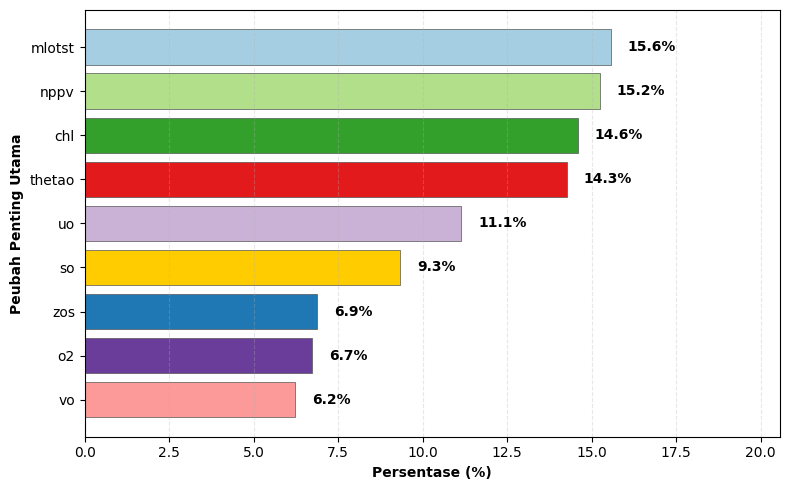

In [ ]:
import matplotlib.pyplot as plt

# 1. Hitung persentase
freq_pct = visual2['Max_Fitur_Gaussian'].value_counts(normalize=True) * 100

# 2. Urutkan (biar terbesar di atas)
freq_pct_sorted = freq_pct.sort_values(ascending=True)

# 3. Gunakan mapping warna yang sama dengan peta
colors_feature = {
    'zos': '#1f78b4',
    'thetao': '#e31a1c',
    'chl': '#33a02c',
    'o2': '#6a3d9a',
    'nppv': '#b2df8a',
    'mlotst': '#a6cee3',
    'vo': '#fb9a99',
    'uo': '#cab2d6',
    'so': '#ffcc00'
}

# Buat list warna sesuai urutan fitur yang sudah diurutkan
bar_colors = [colors_feature.get(feature, '#bdbdbd') for feature in freq_pct_sorted.index]

# 4. Plot
plt.figure(figsize=(8,5))

bars = plt.barh(
    freq_pct_sorted.index,
    freq_pct_sorted.values,
    color=bar_colors,      # Menggunakan mapping warna sinkron
    edgecolor='#555555',
    linewidth=0.5
)

plt.xlabel('Persentase (%)', fontweight='bold')
plt.ylabel('Peubah Penting Utama', fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.3)

# 5. Label persen di ujung bar
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{width:.1f}%',
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.xlim(0, freq_pct_sorted.max() + 5) # Beri ruang untuk label teks
plt.tight_layout()
plt.show()